# CSE 422: Artificial Intelligence: Lab Project
## Career Switch Prediction: Will an Employee Change Their Career?


Predict whether a candidate intends to switch career using supervised (KNN, Decision Tree, Logistic Regression, Neural Network) and unsupervised (K-Means) learning.

In [1]:
# Install required libraries (skip if already installed)
!pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow

## 1. Importing Libraries and Loading the Dataset

In [2]:
# ---- Core data handling ----
import pandas as pd
import numpy as np
import warnings, json, os

# Silence TensorFlow's C++ logging so the notebook output stays readable.
# This must be set BEFORE tensorflow is imported (Section 6.4).
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Silence TensorFlow's C++ logging so the notebook output stays readable.
# This must be set BEFORE tensorflow is imported (Section 6.4).
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ---- Visualisation ----
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Pre-processing (Ref: Lecture 1, Introduction to ML & Preprocessing) ----
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ---- Supervised models ----
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

# ---- Unsupervised model (Ref: Lecture 2, K-Means Clustering Lab) ----
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---- Evaluation (Ref: Lecture 3, Model Evaluation Lab) ----
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc, silhouette_score)

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('figures', exist_ok=True)

# ---- Global plotting style ----
# Colour-blind-safe categorical palette, assigned in a FIXED order (never cycled).
C_BLUE, C_ORANGE, C_AQUA, C_VIOLET = '#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7'
MODEL_COLORS = [C_BLUE, C_ORANGE, C_AQUA, C_VIOLET]
CLUSTER_COLORS = [C_BLUE, C_ORANGE, C_AQUA]

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.edgecolor': '#999999', 'figure.facecolor': 'white',
})

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# The CSV is hosted on Google Drive for portability.
# If you already have the file locally, just set  DATA_PATH = 'Career_Switch_Prediction_Dataset.csv'

import os, urllib.request

DATA_PATH = 'Career_Switch_Prediction_Dataset.csv'
DRIVE_ID  = '10nCTuxcDEGWwFxotKvasc41siV0nr6fg'

if not os.path.exists(DATA_PATH):
    url = f'https://drive.google.com/uc?export=download&id={DRIVE_ID}'
    print(f'Downloading dataset from Google Drive...')
    urllib.request.urlretrieve(url, DATA_PATH)
    print(f'Saved to {DATA_PATH}')
else:
    print(f'Dataset already exists at {DATA_PATH}')

dataset = pd.read_csv(DATA_PATH)
dataset.head(10)

Saved to Career_Switch_Prediction_Dataset.csv


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0


## 2. Dataset Description

### 2.1 How many data points and how many features?

In [4]:
print('Shape of the dataset is {}. This dataset contains {} rows (data points) '
      'and {} columns.'.format(dataset.shape, dataset.shape[0], dataset.shape[1]))
print()
print('Number of input features (excluding the target):', dataset.shape[1] - 1)
print('Target / output feature: will_change_career')

Shape of the dataset is (5000, 14). This dataset contains 5000 rows (data points) and 14 columns.

Number of input features (excluding the target): 13
Target / output feature: will_change_career


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             5000 non-null   int64  
 1   city                    5000 non-null   object 
 2   city_development_index  5000 non-null   float64
 3   gender                  3887 non-null   object 
 4   relevent_experience     5000 non-null   object 
 5   enrolled_university     4893 non-null   object 
 6   education_level         4882 non-null   object 
 7   major_discipline        4276 non-null   object 
 8   experience              4989 non-null   object 
 9   company_size            3429 non-null   object 
 10  company_type            3379 non-null   object 
 11  last_new_job            4896 non-null   object 
 12  training_hours          5000 non-null   int64  
 13  will_change_career      5000 non-null   int64  
dtypes: float64(1), int64(3), object(10)
memo

### 2.2 Is this a classification or a regression problem?

In [6]:
print("Unique values in the target feature 'will_change_career':",
      sorted(dataset['will_change_career'].unique()))
print("Number of unique values:", dataset['will_change_career'].nunique())
print("Data type:", dataset['will_change_career'].dtype)

Unique values in the target feature 'will_change_career': [np.int64(0), np.int64(1)]
Number of unique values: 2
Data type: int64


### 2.3 What kind of features are in the dataset? (Quantitative / Categorical)

In [7]:
# Selecting numerical (quantitative) features
numerical_data = dataset.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical (quantitative) features:\n')
print(numerical_features)

There are 4 numerical (quantitative) features:

['enrollee_id', 'city_development_index', 'training_hours', 'will_change_career']


In [8]:
# Selecting categorical features
categorical_data = dataset.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()
print(f'There are {len(categorical_features)} categorical features:\n')
print(categorical_features)

There are 10 categorical features:

['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


| Feature | Type | Notes |
|---|---|---|
| `enrollee_id` | Quantitative (nominal ID) | Unique identifier — no predictive value |
| `city` | Categorical (nominal) | 113 distinct city codes |
| `city_development_index` | Quantitative (continuous) | Development score, 0–1 |
| `gender` | Categorical (nominal) | Male / Female / Other |
| `relevent_experience` | Categorical (binary) | Has / has no relevant experience |
| `enrolled_university` | Categorical (ordinal) | no_enrollment < Part time < Full time |
| `education_level` | Categorical (ordinal) | Primary School < … < Phd |
| `major_discipline` | Categorical (nominal) | STEM, Humanities, Business Degree, … |
| `experience` | Categorical (ordinal, stored as text) | `<1` … `>20` |
| `company_size` | Categorical (ordinal, stored as text) | `<10` … `10000+` |
| `company_type` | Categorical (nominal) | Pvt Ltd, Funded Startup, Public Sector, … |
| `last_new_job` | Categorical (ordinal, stored as text) | `never` … `>4` |
| `training_hours` | Quantitative (discrete count) | Hours of training completed |
| `will_change_career` | **Target** (binary) | 0 = stays, 1 = switches |

In [9]:
# Summary statistics of the numerical features (transposed for readability)
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,5000.0,17022.88300,9656.969716,7.000,8736.500,17068.000,25389.25,33380.000
city_development_index,5000.0,0.82941,0.122429,0.448,0.743,0.903,0.92,0.949
training_hours,5000.0,65.02720,59.946693,1.000,23.000,47.000,88.00,336.000
will_change_career,5000.0,0.25240,0.434433,0.000,0.000,0.000,1.00,1.000


In [10]:
# Summary statistics of the categorical features
categorical_data.describe().T

,count,unique,top,freq
city,5000,113,city_103,1163
gender,3887,3,Male,3507
relevent_experience,5000,2,Has relevent experience,3598
enrolled_university,4893,3,no_enrollment,3571
education_level,4882,5,Graduate,3037
major_discipline,4276,6,STEM,3786
experience,4989,22,>20,859
company_size,3429,8,50-99,813
company_type,3379,6,Pvt Ltd,2550
last_new_job,4896,6,1,2094


### 2.4 Do we need to encode the categorical variables? Why?

In [11]:
print("Number of purely categorical (text) columns:", len(categorical_features))
print("Number of numeric columns:", len(numerical_features))
print()
print("Total unique categories that would need encoding:")
for c in categorical_features:
    print(f"  {c:<24} {dataset[c].nunique():>4} categories")

Number of purely categorical (text) columns: 10
Number of numeric columns: 4

Total unique categories that would need encoding:
  city                      113 categories
  gender                      3 categories
  relevent_experience         2 categories
  enrolled_university         3 categories
  education_level             5 categories
  major_discipline            6 categories
  experience                 22 categories
  company_size                8 categories
  company_type                6 categories
  last_new_job                6 categories


### 2.5 Correlation of all the features (input and output)

In [12]:
# Build a numeric copy for correlation analysis only
corr_df = dataset.copy()

# Repair a known data-entry corruption: the category "10-49" has been mangled
# into the date-like string "Oct-49" by spreadsheet auto-formatting.
corr_df['company_size'] = corr_df['company_size'].replace({'Oct-49': '10-49'})

# --- Ordinal maps (order is meaningful and is preserved) ---
education_map   = {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
enrolled_map    = {'no_enrollment': 0, 'Part time course': 1, 'Full time course': 2}
relevent_map    = {'No relevent experience': 0, 'Has relevent experience': 1}
company_size_map = {'<10': 0, '10-49': 1, '50-99': 2, '100-500': 3,
                    '500-999': 4, '1000-4999': 5, '5000-9999': 6, '10000+': 7}
experience_map  = {'<1': 0, '>20': 21}
lastjob_map     = {'never': 0, '>4': 5}

corr_df['education_level']     = corr_df['education_level'].map(education_map)
corr_df['enrolled_university'] = corr_df['enrolled_university'].map(enrolled_map)
corr_df['relevent_experience'] = corr_df['relevent_experience'].map(relevent_map)
corr_df['company_size']        = corr_df['company_size'].map(company_size_map)
corr_df['experience']          = corr_df['experience'].replace(experience_map).astype(float)
corr_df['last_new_job']        = corr_df['last_new_job'].replace(lastjob_map).astype(float)

# Nominal features -> label encoded ONLY for the correlation display
for col in ['gender', 'major_discipline', 'company_type']:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col].astype(str))

corr_df = corr_df.drop(['enrollee_id', 'city'], axis=1)
correlation_matrix = corr_df.corr()
correlation_matrix.round(3)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
city_development_index,1.000,-0.150,0.075,-0.190,0.045,-0.102,0.333,0.082,-0.054,0.184,0.005,-0.347
gender,-0.150,1.000,-0.087,0.094,-0.039,0.034,-0.150,0.003,0.055,-0.113,0.013,0.063
relevent_experience,0.075,-0.087,1.000,-0.396,0.243,-0.125,0.351,-0.057,-0.210,0.266,0.020,-0.113
enrolled_university,-0.190,0.094,-0.396,1.000,-0.178,0.151,-0.347,-0.054,0.116,-0.248,-0.020,0.154
education_level,0.045,-0.039,0.243,-0.178,1.000,-0.272,0.284,0.062,-0.119,0.219,-0.025,-0.007
major_discipline,-0.102,0.034,-0.125,0.151,-0.272,1.000,-0.092,-0.002,0.082,-0.109,0.011,0.013
experience,0.333,-0.150,0.351,-0.347,0.284,-0.092,1.000,0.074,-0.056,0.469,-0.005,-0.178
company_size,0.082,0.003,-0.057,-0.054,0.062,-0.002,0.074,1.000,0.259,0.080,-0.012,-0.035
company_type,-0.054,0.055,-0.210,0.116,-0.119,0.082,-0.056,0.259,1.000,-0.035,-0.012,0.120
last_new_job,0.184,-0.113,0.266,-0.248,0.219,-0.109,0.469,0.080,-0.035,1.000,0.006,-0.053


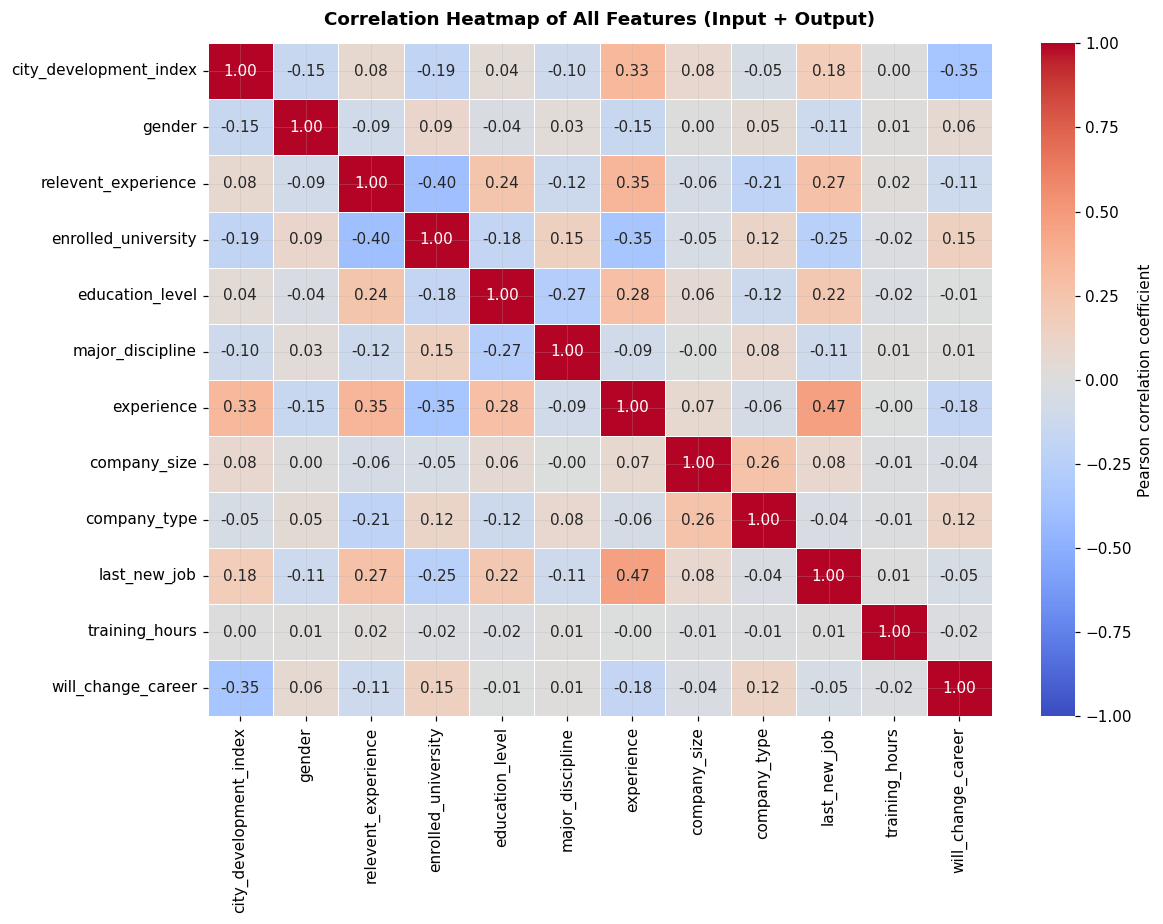

In [13]:
# Correlation heatmap using seaborn (Ref: EDA Lab CSE422)
# Diverging colour map: two hues with a neutral midpoint at zero correlation.
plt.figure(figsize=(11, 8.5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson correlation coefficient'})
plt.title('Correlation Heatmap of All Features (Input + Output)', pad=12)
plt.tight_layout()
plt.savefig('figures/fig01_correlation_heatmap.png')
plt.show()

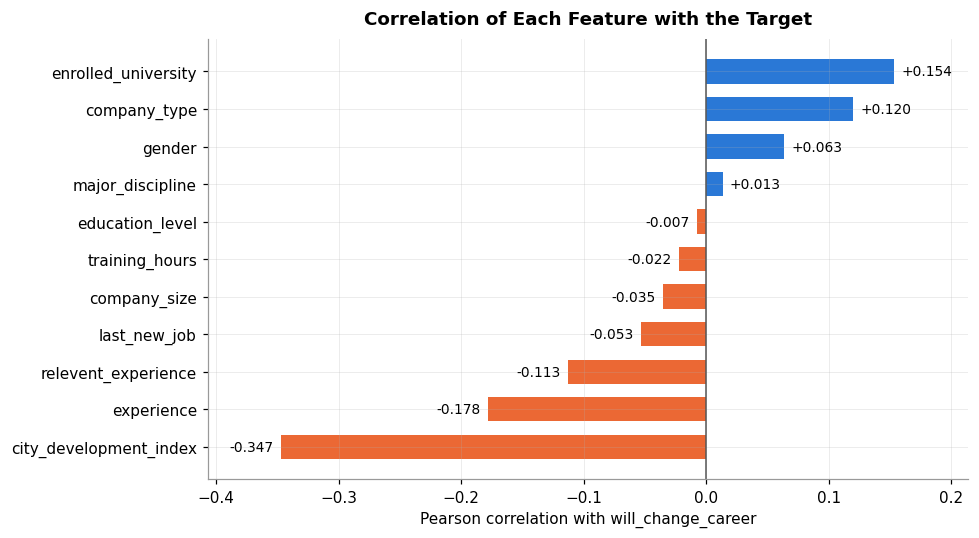

city_development_index   -0.3468
experience               -0.1784
relevent_experience      -0.1129
last_new_job             -0.0533
company_size             -0.0355
training_hours           -0.0222
education_level          -0.0074
major_discipline          0.0133
gender                    0.0634
company_type              0.1198
enrolled_university       0.1537


In [14]:
# Correlation of every feature specifically against the TARGET, sorted.
target_corr = correlation_matrix['will_change_career'].drop('will_change_career').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [C_ORANGE if v < 0 else C_BLUE for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, height=0.65)
ax.axvline(0, color='#555555', linewidth=1)
ax.set_xlabel('Pearson correlation with will_change_career')
ax.set_title('Correlation of Each Feature with the Target', pad=10)
for b, v in zip(bars, target_corr.values):
    ax.text(v + (0.006 if v >= 0 else -0.006), b.get_y() + b.get_height()/2,
            f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_xlim(target_corr.min() - 0.06, target_corr.max() + 0.06)
plt.tight_layout()
plt.savefig('figures/fig02_target_correlation.png')
plt.show()

print(target_corr.round(4).to_string())

### 2.6 What do we understand from the correlation test?

### 2.7 Imbalanced Dataset

In [15]:
# Check imbalance in the data (Ref: EDA Lab CSE422)
class_counts = dataset.groupby('will_change_career').size()

columns = ['will_change_career', 'count', 'percentage']
outcome, count, percentage = [0, 1], [], []
for val in range(2):
    count.append(class_counts[val])
    percentage.append((class_counts[val] / len(dataset)) * 100)

imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)), columns=columns)
imbalance_df

,will_change_career,count,percentage
0,0,3738,74.76
1,1,1262,25.24


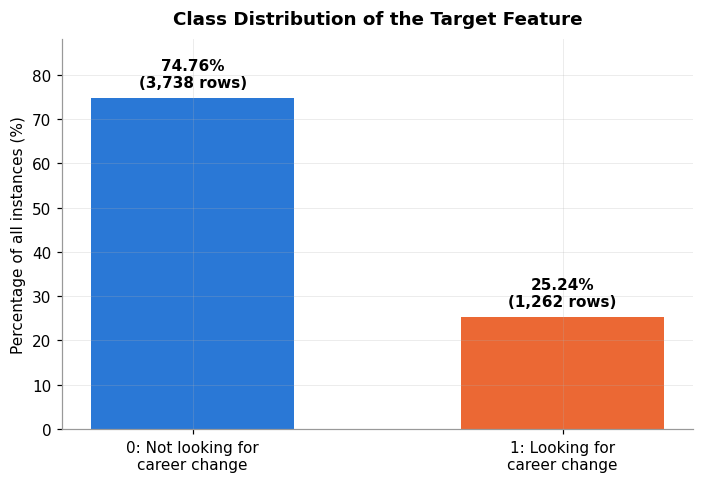

Majority : Minority ratio = 2.96 : 1


In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(['0: Not looking for\ncareer change', '1: Looking for\ncareer change'],
              imbalance_df['percentage'], color=[C_BLUE, C_ORANGE], width=0.55)
ax.set_ylabel('Percentage of all instances (%)')
ax.set_title('Class Distribution of the Target Feature', pad=10)
ax.set_ylim(0, 88)
for b, cnt, pct in zip(bars, imbalance_df['count'], imbalance_df['percentage']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.8,
            f'{pct:.2f}%\n({cnt:,} rows)', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig03_class_imbalance.png')
plt.show()

ratio = imbalance_df['count'][0] / imbalance_df['count'][1]
print(f"Majority : Minority ratio = {ratio:.2f} : 1")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing values

In [17]:
missing = pd.DataFrame({
    'missing_count': dataset.isnull().sum(),
    'missing_percentage': (dataset.isnull().mean() * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing

,missing_count,missing_percentage
company_type,1621,32.42
company_size,1571,31.42
gender,1113,22.26
major_discipline,724,14.48
education_level,118,2.36
enrolled_university,107,2.14
last_new_job,104,2.08
experience,11,0.22


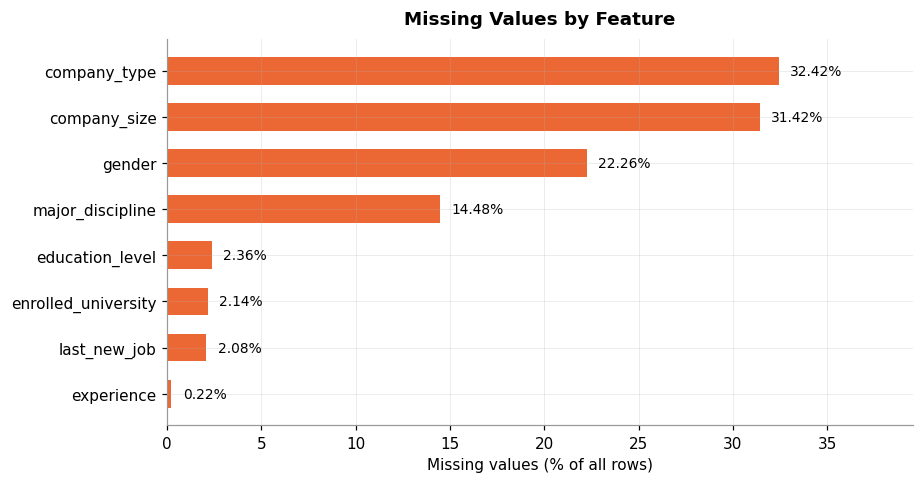

Total cells missing: 5369
Rows with at least one missing value: 2609 (52.18% of the dataset)
Duplicate rows: 0


In [18]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.barh(missing.index[::-1], missing['missing_percentage'][::-1],
               color=C_ORANGE, height=0.6)
ax.set_xlabel('Missing values (% of all rows)')
ax.set_title('Missing Values by Feature', pad=10)
ax.set_xlim(0, max(missing['missing_percentage']) * 1.22)
for b, v in zip(bars, missing['missing_percentage'][::-1]):
    ax.text(v + 0.6, b.get_y() + b.get_height()/2, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig04_missing_values.png')
plt.show()

print("Total cells missing:", int(dataset.isnull().sum().sum()))
print("Rows with at least one missing value:", int(dataset.isnull().any(axis=1).sum()),
      f"({dataset.isnull().any(axis=1).mean()*100:.2f}% of the dataset)")
print("Duplicate rows:", int(dataset.duplicated().sum()))

### 3.2 Descriptive analysis: variance and skewness of the numerical features

In [19]:
print("Variance of each numerical feature:\n")
print(numerical_data.var().to_string())

Variance of each numerical feature:

enrollee_id               9.325706e+07
city_development_index    1.498895e-02
training_hours            3.593606e+03
will_change_career        1.887320e-01


In [20]:
print("Skewness of each numerical feature:\n")
print(numerical_data.skew().to_string())

Skewness of each numerical feature:

enrollee_id              -0.022808
city_development_index   -1.013328
training_hours            1.853677
will_change_career        1.140333


### 3.3 Histograms: distribution of each numerical feature

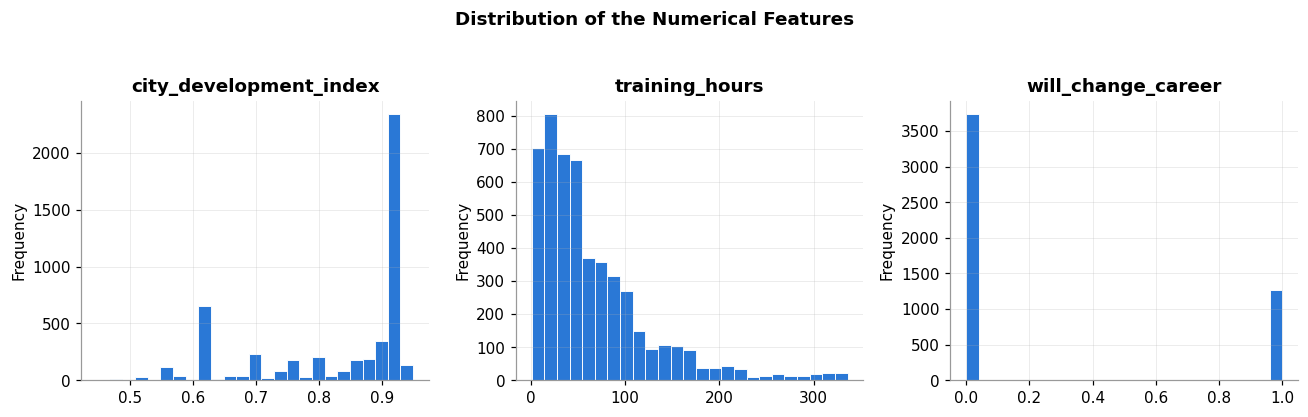

In [21]:
plot_nums = dataset[['city_development_index', 'training_hours', 'will_change_career']]
axes = plot_nums.hist(figsize=(12, 3.6), bins=25, layout=(1, 3),
                      color=C_BLUE, edgecolor='white', linewidth=0.6)
for ax in axes.flatten():
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.25)
plt.suptitle('Distribution of the Numerical Features', y=1.04, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig05_histograms.png')
plt.show()

### 3.4 Box plots: outlier detection

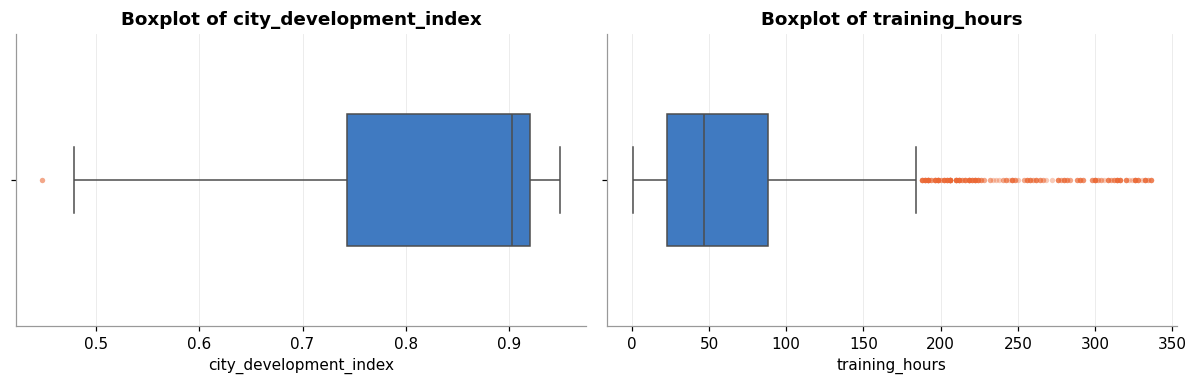

Outlier count using the 1.5 x IQR rule:

  city_development_index        2 outliers ( 0.04%)   acceptable range: [0.477, 1.186]
  training_hours              250 outliers ( 5.00%)   acceptable range: [-74.500, 185.500]


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col in zip(axes, ['city_development_index', 'training_hours']):
    sns.boxplot(x=dataset[col], color=C_BLUE, ax=ax, width=0.45,
                flierprops=dict(marker='o', markersize=3.5, alpha=0.35,
                                markerfacecolor=C_ORANGE, markeredgecolor='none'))
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('figures/fig06_boxplots.png')
plt.show()

# Quantify the outliers using the IQR rule
print("Outlier count using the 1.5 x IQR rule:\n")
for col in ['city_development_index', 'training_hours']:
    q1, q3 = dataset[col].quantile(0.25), dataset[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((dataset[col] < lo) | (dataset[col] > hi)).sum()
    print(f"  {col:<26} {n_out:>4} outliers ({n_out/len(dataset)*100:5.2f}%)   "
          f"acceptable range: [{lo:.3f}, {hi:.3f}]")

### 3.5 Density plots

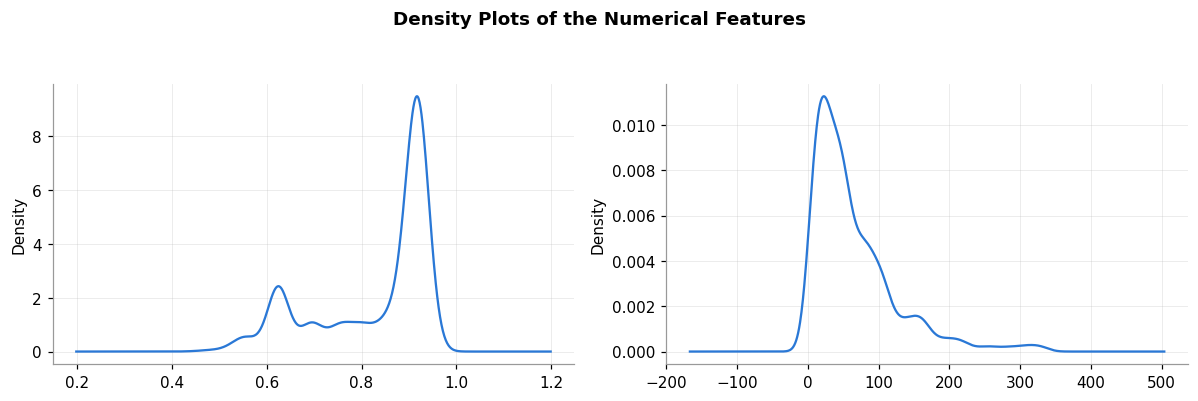

In [23]:
plot_nums[['city_development_index', 'training_hours']].plot(
    kind='density', figsize=(11, 3.4), subplots=True, layout=(1, 2),
    sharex=False, color=C_BLUE, legend=False)
plt.suptitle('Density Plots of the Numerical Features', y=1.06, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig07_density.png')
plt.show()

### 3.6 Distribution of the categorical features

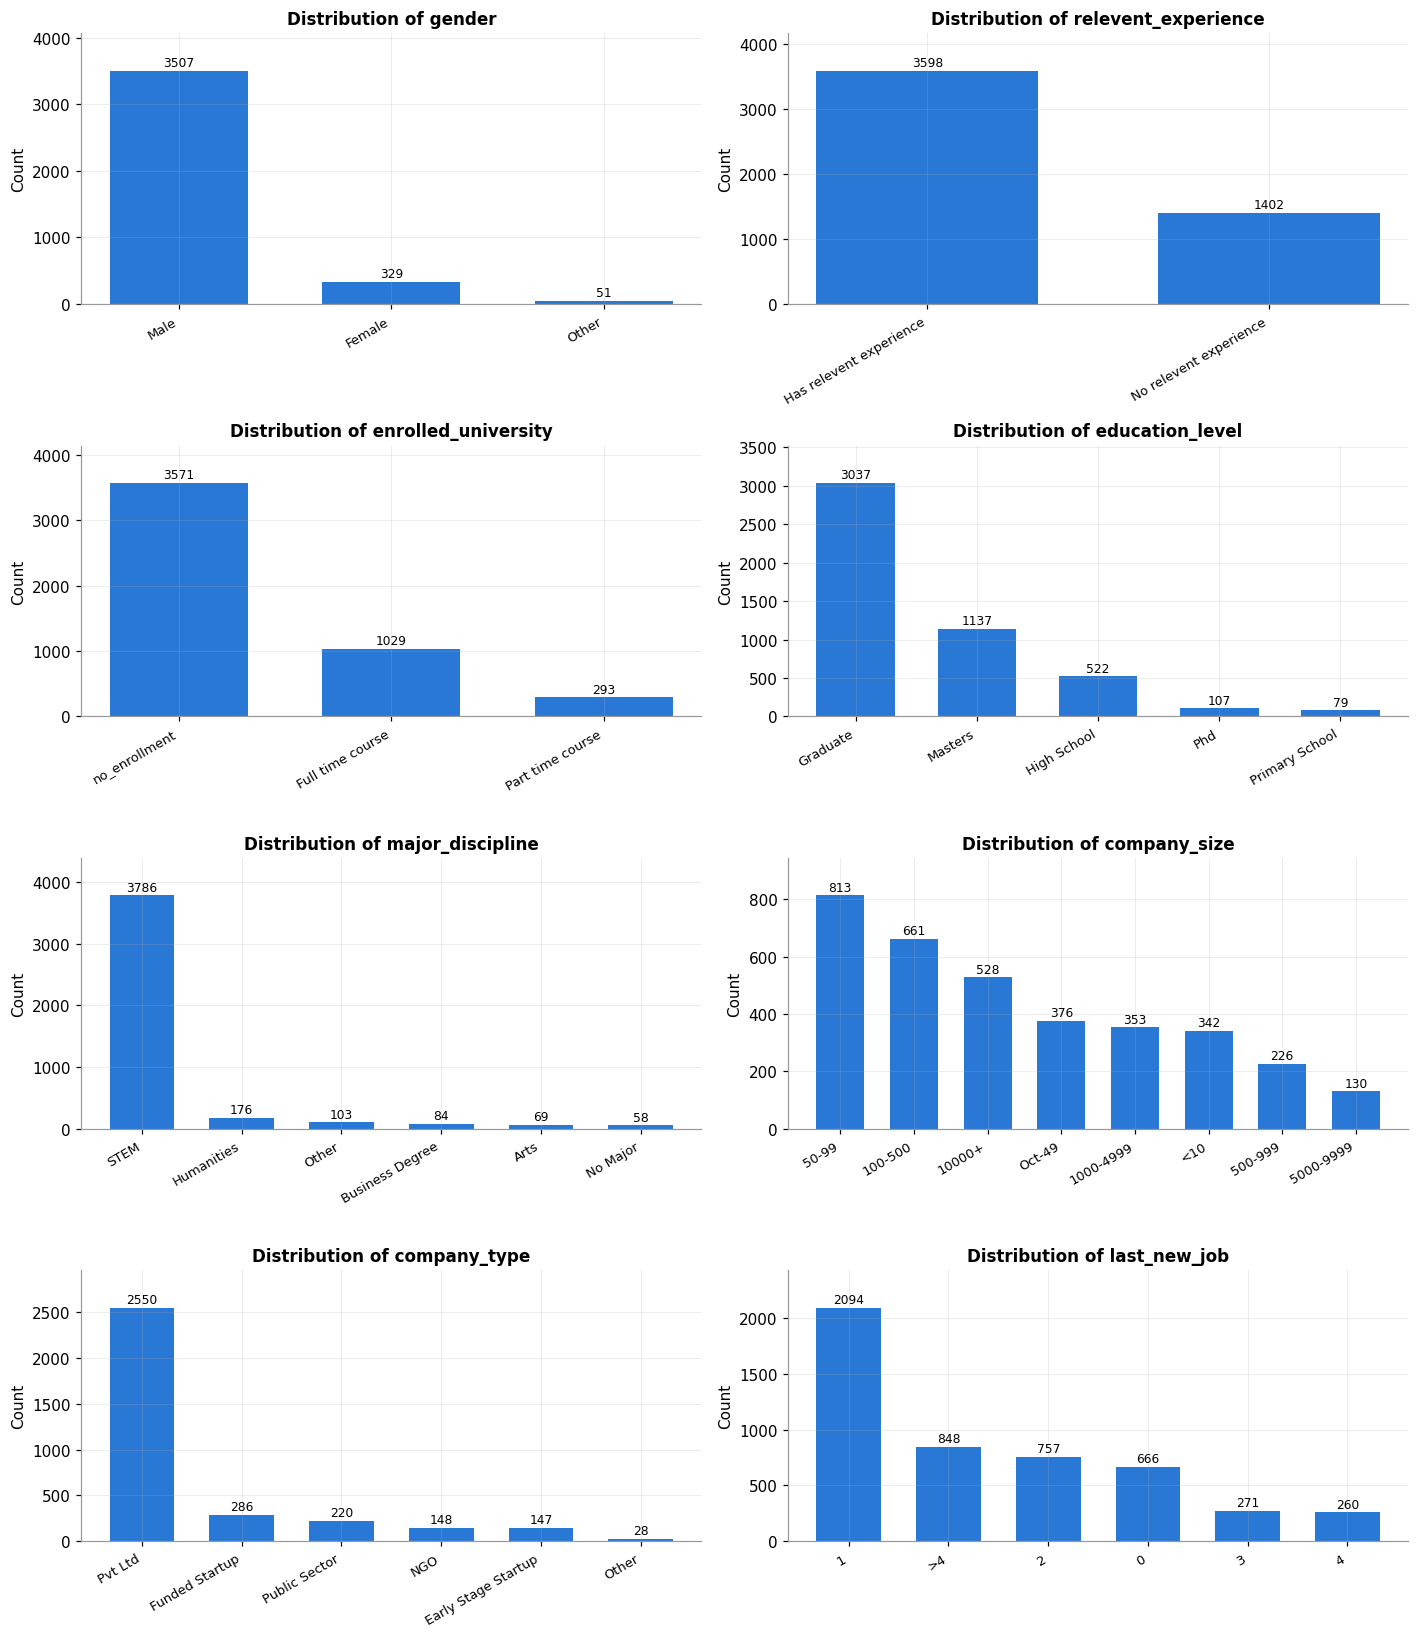

In [24]:
cat_to_plot = ['gender', 'relevent_experience', 'enrolled_university', 'education_level',
               'major_discipline', 'company_size', 'company_type', 'last_new_job']

fig, axes = plt.subplots(4, 2, figsize=(13, 15))
for ax, col in zip(axes.flatten(), cat_to_plot):
    vc = dataset[col].value_counts()
    ax.bar(range(len(vc)), vc.values, color=C_BLUE, width=0.65)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=30, ha='right', fontsize=8.5)
    ax.set_title(f'Distribution of {col}', fontsize=11)
    ax.set_ylabel('Count')
    for i, v in enumerate(vc.values):
        ax.text(i, v + max(vc.values) * 0.02, str(v), ha='center', fontsize=8)
    ax.set_ylim(0, max(vc.values) * 1.16)
plt.tight_layout()
plt.savefig('figures/fig08_categorical_distributions.png')
plt.show()

### 3.7 Relationship between the key features and the target

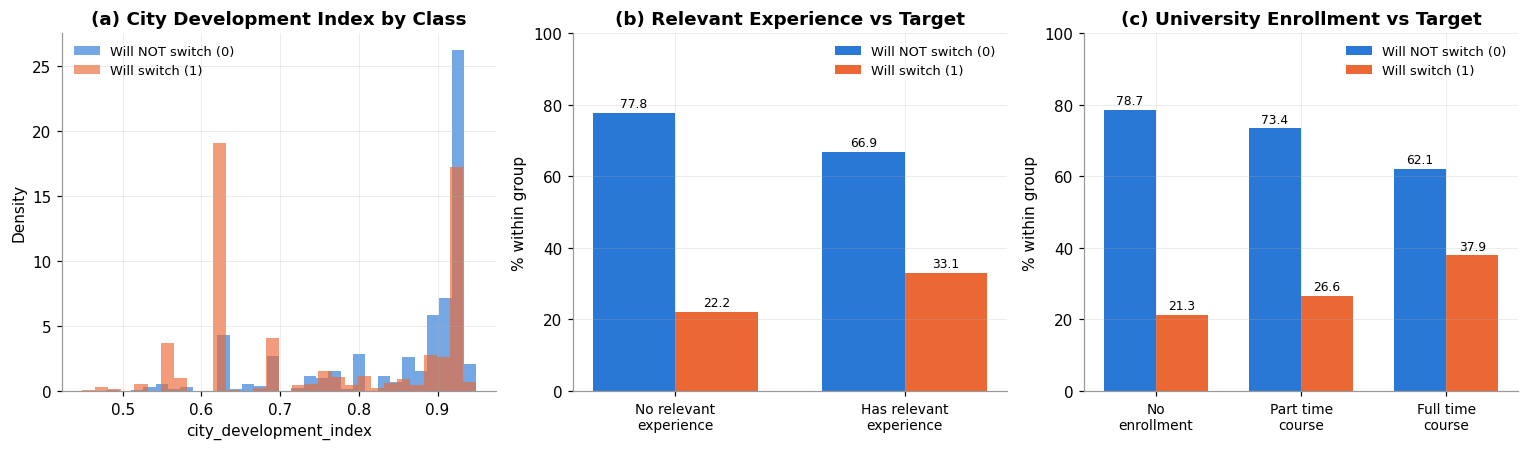

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) city_development_index vs target
for cls, colr, lbl in [(0, C_BLUE, 'Will NOT switch (0)'), (1, C_ORANGE, 'Will switch (1)')]:
    axes[0].hist(dataset[dataset.will_change_career == cls]['city_development_index'],
                 bins=30, alpha=0.65, color=colr, label=lbl, density=True)
axes[0].set_xlabel('city_development_index'); axes[0].set_ylabel('Density')
axes[0].set_title('(a) City Development Index by Class')
axes[0].legend(fontsize=8.5, frameon=False)

# (b) relevant experience vs target
ct = pd.crosstab(dataset['relevent_experience'], dataset['will_change_career'], normalize='index') * 100
x = np.arange(len(ct)); w = 0.36
axes[1].bar(x - w/2, ct[0], w, label='Will NOT switch (0)', color=C_BLUE)
axes[1].bar(x + w/2, ct[1], w, label='Will switch (1)', color=C_ORANGE)
axes[1].set_xticks(x); axes[1].set_xticklabels(['No relevant\nexperience', 'Has relevant\nexperience'], fontsize=9)
axes[1].set_ylabel('% within group'); axes[1].set_title('(b) Relevant Experience vs Target')
axes[1].legend(fontsize=8.5, frameon=False)
for i in range(len(ct)):
    axes[1].text(i - w/2, ct[0].iloc[i] + 1.5, f'{ct[0].iloc[i]:.1f}', ha='center', fontsize=8)
    axes[1].text(i + w/2, ct[1].iloc[i] + 1.5, f'{ct[1].iloc[i]:.1f}', ha='center', fontsize=8)
axes[1].set_ylim(0, 100)

# (c) enrolled_university vs target
ct2 = pd.crosstab(dataset['enrolled_university'], dataset['will_change_career'], normalize='index') * 100
ct2 = ct2.loc[['no_enrollment', 'Part time course', 'Full time course']]
x2 = np.arange(len(ct2))
axes[2].bar(x2 - w/2, ct2[0], w, label='Will NOT switch (0)', color=C_BLUE)
axes[2].bar(x2 + w/2, ct2[1], w, label='Will switch (1)', color=C_ORANGE)
axes[2].set_xticks(x2); axes[2].set_xticklabels(['No\nenrollment', 'Part time\ncourse', 'Full time\ncourse'], fontsize=9)
axes[2].set_ylabel('% within group'); axes[2].set_title('(c) University Enrollment vs Target')
axes[2].legend(fontsize=8.5, frameon=False)
for i in range(len(ct2)):
    axes[2].text(i - w/2, ct2[0].iloc[i] + 1.5, f'{ct2[0].iloc[i]:.1f}', ha='center', fontsize=8)
    axes[2].text(i + w/2, ct2[1].iloc[i] + 1.5, f'{ct2[1].iloc[i]:.1f}', ha='center', fontsize=8)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('figures/fig09_feature_vs_target.png')
plt.show()

In [26]:
# Numeric backing for the plots above
print("Mean city_development_index by class:")
print(dataset.groupby('will_change_career')['city_development_index'].agg(['mean', 'median', 'std']).round(4).to_string())
print("\nSwitch rate (%) by relevant experience:")
print((pd.crosstab(dataset['relevent_experience'], dataset['will_change_career'], normalize='index')[1] * 100).round(2).to_string())
print("\nSwitch rate (%) by university enrollment:")
print((pd.crosstab(dataset['enrolled_university'], dataset['will_change_career'], normalize='index')[1] * 100).round(2).to_string())
print("\nSwitch rate (%) by education level:")
print((pd.crosstab(dataset['education_level'], dataset['will_change_career'], normalize='index')[1] * 100).round(2).to_string())
print("\nSwitch rate (%) by company type:")
print((pd.crosstab(dataset['company_type'], dataset['will_change_career'], normalize='index')[1] * 100).round(2).to_string())

Mean city_development_index by class:
                      mean  median     std
will_change_career                        
0                   0.8541    0.91  0.1034
1                   0.7563    0.74  0.1435

Switch rate (%) by relevant experience:
relevent_experience
Has relevent experience    22.18
No relevent experience     33.10

Switch rate (%) by university enrollment:
enrolled_university
Full time course    37.90
Part time course    26.62
no_enrollment       21.34

Switch rate (%) by education level:
education_level
Graduate          28.09
High School       19.92
Masters           22.25
Phd               14.02
Primary School    12.66

Switch rate (%) by company type:
company_type
Early Stage Startup    24.49
Funded Startup         14.69
NGO                    18.24
Other                  28.57
Public Sector          20.00
Pvt Ltd                18.47


## 4. Dataset Pre-processing

In [27]:
# Work on a fresh copy so the original `dataset` stays intact for reference.
df = dataset.copy()
print("Starting shape:", df.shape)

Starting shape: (5000, 14)


### Fault 1: Identifier and high-cardinality columns

Drop `enrollee_id` and `city` (use `city_development_index` instead).

In [28]:
df = df.drop(['enrollee_id', 'city'], axis=1)
print("Shape after dropping identifier / high-cardinality columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping identifier / high-cardinality columns: (5000, 12)
Remaining columns: ['city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'will_change_career']


### Fault 2: Corrupted category value

Fix `"Oct-49"` → `"10-49"` in `company_size`.

In [29]:
print("BEFORE repair, company_size categories:")
print(df['company_size'].value_counts(dropna=False).to_string())

BEFORE repair, company_size categories:
company_size
NaN          1571
50-99         813
100-500       661
10000+        528
Oct-49        376
1000-4999     353
<10           342
500-999       226
5000-9999     130


In [30]:
# Solution: map the corrupted string back to its true category.
df['company_size'] = df['company_size'].replace({'Oct-49': '10-49'})

print("AFTER repair, company_size categories:")
print(df['company_size'].value_counts(dropna=False).to_string())

AFTER repair, company_size categories:
company_size
NaN          1571
50-99         813
100-500       661
10000+        528
10-49         376
1000-4999     353
<10           342
500-999       226
5000-9999     130


### Fault 3: Null / missing values

In [31]:
# Demonstrate why row deletion is not viable here
print("Rows if we dropped every row with any null value:", df.dropna().shape[0],
      f"({df.dropna().shape[0]/len(df)*100:.2f}% of the data retained)")
print("Rows we would LOSE:", len(df) - df.dropna().shape[0])

Rows if we dropped every row with any null value: 2391 (47.82% of the data retained)
Rows we would LOSE: 2609


**(a)** High-missingness columns → `"Unknown"` category. **(b)** Low-missingness columns → mode imputation.

In [32]:
# --- (a) Meaningful missingness -> explicit "Unknown" category ---
informative_missing = ['gender', 'major_discipline', 'company_size', 'company_type']
for col in informative_missing:
    df[col] = df[col].fillna('Unknown')
print("Filled with an explicit 'Unknown' category:", informative_missing)
print()

# --- (b) Small missingness -> SimpleImputer with the most frequent value ---
mode_impute = ['enrolled_university', 'education_level', 'last_new_job', 'experience']
impute = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df[mode_impute] = impute.fit_transform(df[mode_impute])
print("Mode-imputed with SimpleImputer:", mode_impute)
print("Values used by the imputer:", dict(zip(mode_impute, impute.statistics_)))

Filled with an explicit 'Unknown' category: ['gender', 'major_discipline', 'company_size', 'company_type']

Mode-imputed with SimpleImputer: ['enrolled_university', 'education_level', 'last_new_job', 'experience']
Values used by the imputer: {'enrolled_university': 'no_enrollment', 'education_level': 'Graduate', 'last_new_job': '1', 'experience': '>20'}


In [33]:
print("Null values remaining in the entire dataset:", int(df.isnull().sum().sum()))
print("Shape after handling missing values:", df.shape, "(no rows were lost)")
df.isnull().sum()

Null values remaining in the entire dataset: 0
Shape after handling missing values: (5000, 12) (no rows were lost)


,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0
company_type,0
last_new_job,0


### Fault 4: Categorical values

#### 4.4.1 Ordinal features → `.map()`

In [34]:
# relevent_experience : binary, ordered
df['relevent_experience'] = df['relevent_experience'].map(
    {'No relevent experience': 0, 'Has relevent experience': 1})

# enrolled_university : none < part time < full time
df['enrolled_university'] = df['enrolled_university'].map(
    {'no_enrollment': 0, 'Part time course': 1, 'Full time course': 2})

# education_level : Primary School < High School < Graduate < Masters < Phd
df['education_level'] = df['education_level'].map(
    {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4})

# experience : '<1' -> 0, '1'..'20' stay, '>20' -> 21
df['experience'] = df['experience'].replace({'<1': 0, '>20': 21}).astype(int)

# last_new_job : 'never' -> 0, '1'..'4' stay, '>4' -> 5
df['last_new_job'] = df['last_new_job'].replace({'never': 0, '>4': 5}).astype(int)

# company_size : ordered by size, with 'Unknown' kept as its own level (-1)
df['company_size'] = df['company_size'].map(
    {'Unknown': -1, '<10': 0, '10-49': 1, '50-99': 2, '100-500': 3,
     '500-999': 4, '1000-4999': 5, '5000-9999': 6, '10000+': 7})

ordinal_cols = ['relevent_experience', 'enrolled_university', 'education_level',
                'experience', 'last_new_job', 'company_size']
print("Ordinal features encoded with .map(), preserving their order:")
df[ordinal_cols].head(10)

Ordinal features encoded with .map(), preserving their order:


,relevent_experience,enrolled_university,education_level,experience,last_new_job,company_size
0,1,0,2,21,1,-1
1,0,0,2,15,5,2
2,0,2,2,5,0,-1
3,0,0,2,0,0,-1
4,1,0,3,21,4,2
5,1,1,2,11,1,-1
6,1,0,1,5,1,2
7,1,0,2,13,5,0
8,1,0,2,7,1,2
9,1,0,2,17,5,7


#### 4.4.2 Nominal features → one-hot encoding

In [35]:
nominal_cols = ['gender', 'major_discipline', 'company_type']
print("Categories to be one-hot encoded:")
for c in nominal_cols:
    print(f"  {c:<20} -> {df[c].nunique()} categories: {sorted(df[c].unique())}")

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print("\nShape after one-hot encoding:", df.shape)
print("\nAll feature columns now present:")
print(df.columns.tolist())

Categories to be one-hot encoded:
  gender               -> 4 categories: ['Female', 'Male', 'Other', 'Unknown']
  major_discipline     -> 7 categories: ['Arts', 'Business Degree', 'Humanities', 'No Major', 'Other', 'STEM', 'Unknown']
  company_type         -> 7 categories: ['Early Stage Startup', 'Funded Startup', 'NGO', 'Other', 'Public Sector', 'Pvt Ltd', 'Unknown']

Shape after one-hot encoding: (5000, 24)

All feature columns now present:
['city_development_index', 'relevent_experience', 'enrolled_university', 'education_level', 'experience', 'company_size', 'last_new_job', 'training_hours', 'will_change_career', 'gender_Male', 'gender_Other', 'gender_Unknown', 'major_discipline_Business Degree', 'major_discipline_Humanities', 'major_discipline_No Major', 'major_discipline_Other', 'major_discipline_STEM', 'major_discipline_Unknown', 'company_type_Funded Startup', 'company_type_NGO', 'company_type_Other', 'company_type_Public Sector', 'company_type_Pvt Ltd', 'company_type_Unknown']

In [36]:
df.head(10)

,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,will_change_career,gender_Male,gender_Other,gender_Unknown,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,0.920,1,0,2,21,-1,1,36,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0.776,0,0,2,15,2,5,47,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
2,0.624,0,2,2,5,-1,0,83,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
3,0.789,0,0,2,0,-1,0,52,1,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0
4,0.767,1,0,3,21,2,4,8,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0
5,0.764,1,1,2,11,-1,1,24,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
6,0.920,1,0,1,5,2,1,24,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0
7,0.762,1,0,2,13,0,5,18,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
8,0.920,1,0,2,7,2,1,46,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
9,0.920,1,0,2,17,7,5,123,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0


### Fault 5: Feature scaling

In [37]:
scale_check = pd.DataFrame({
    'min': df.drop('will_change_career', axis=1).min(),
    'max': df.drop('will_change_career', axis=1).max(),
    'variance': df.drop('will_change_career', axis=1).var()
}).sort_values('variance', ascending=False)
scale_check.head(8).round(3)

,min,max,variance
training_hours,1.0,336.0,3593.606
experience,0.0,21.0,46.125
company_size,-1.0,7.0,7.175
last_new_job,0.0,5.0,2.760
enrolled_university,0.0,2.0,0.661
education_level,0.0,4.0,0.463
company_type_Pvt Ltd,0.0,1.0,0.250
company_type_Unknown,0.0,1.0,0.219


Apply `StandardScaler` (fit on train only, transform both).

## 5. Dataset Splitting

Stratified 80/20 split (`random_state=42`).

In [38]:
X = df.drop('will_change_career', axis=1)
y = df['will_change_career']

print("Feature matrix X shape:", X.shape)
print("Target vector y shape :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("\nTraining set:", X_train.shape[0], "rows  (80%)")
print("Test set    :", X_test.shape[0], "rows  (20%)")

Feature matrix X shape: (5000, 23)
Target vector y shape : (5000,)

Training set: 4000 rows  (80%)
Test set    : 1000 rows  (20%)


In [39]:
# Confirm that stratification preserved the class ratio
split_check = pd.DataFrame({
    'Full dataset (%)': (y.value_counts(normalize=True) * 100).round(2),
    'Train set (%)':    (y_train.value_counts(normalize=True) * 100).round(2),
    'Test set (%)':     (y_test.value_counts(normalize=True) * 100).round(2),
    'Train count':      y_train.value_counts(),
    'Test count':       y_test.value_counts(),
})
split_check.index.name = 'Class'
split_check

,Full dataset (%),Train set (%),Test set (%),Train count,Test count
Class,,,,,
0,74.76,74.75,74.8,2990,748
1,25.24,25.25,25.2,1010,252


In [40]:
# Apply feature scaling: fit on TRAIN only, then transform both (no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Per-feature mean of the scaled training data (should be ~0):",
      np.round(X_train_scaled.mean(axis=0)[:5], 6), "...")
print("Per-feature std  of the scaled training data (should be ~1):",
      np.round(X_train_scaled.std(axis=0)[:5], 6), "...")
print("\nScaled training matrix shape:", X_train_scaled.shape)
print("Scaled test matrix shape    :", X_test_scaled.shape)

Per-feature mean of the scaled training data (should be ~0): [-0. -0. -0. -0.  0.] ...
Per-feature std  of the scaled training data (should be ~1): [1. 1. 1. 1. 1.] ...

Scaled training matrix shape: (4000, 23)
Scaled test matrix shape    : (1000, 23)


## 6. Model Training & Testing

Four supervised models + one unsupervised (K-Means).

In [41]:
results = {}   # model name -> metric dictionary
roc_data = {}  # model name -> (fpr, tpr, auc)

def evaluate_model(name, model, y_true, y_pred, y_proba):
    """Compute and store every metric the report template requires."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                     'F1-Score': f1, 'AUC': roc_auc}
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"===== {name} =====")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  AUC      : {roc_auc:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                target_names=['Will not switch (0)', 'Will switch (1)'],
                                zero_division=0))
    return results[name]

### 6.1 Model 1: K-Nearest Neighbours (KNN)

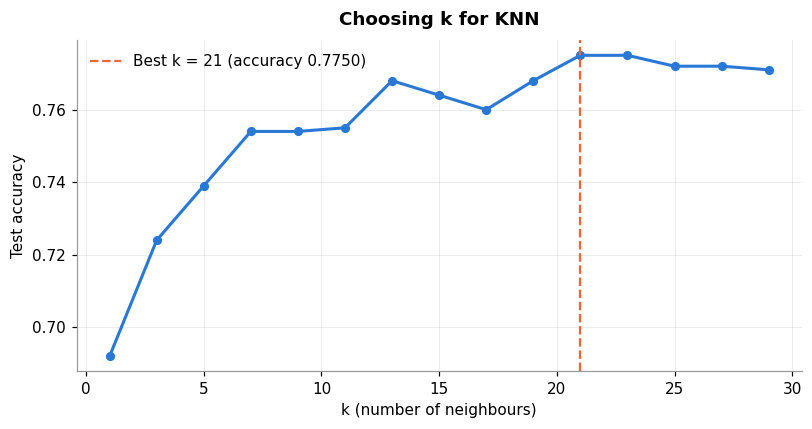

Best k = 21 with test accuracy 0.7750


In [42]:
k_range = range(1, 31, 2)
k_scores = []
for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    k_scores.append(accuracy_score(y_test, knn_tmp.predict(X_test_scaled)))

best_k = list(k_range)[int(np.argmax(k_scores))]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(list(k_range), k_scores, marker='o', markersize=5, linewidth=2, color=C_BLUE)
ax.axvline(best_k, color=C_ORANGE, linestyle='--', linewidth=1.5,
           label=f'Best k = {best_k} (accuracy {max(k_scores):.4f})')
ax.set_xlabel('k (number of neighbours)'); ax.set_ylabel('Test accuracy')
ax.set_title('Choosing k for KNN', pad=10)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/fig10_knn_k_selection.png')
plt.show()

print(f"Best k = {best_k} with test accuracy {max(k_scores):.4f}")

In [43]:
# Train the final KNN model with the chosen k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

evaluate_model('KNN', knn, y_test, y_pred_knn, y_proba_knn)

===== KNN =====
  Accuracy : 0.7750  (77.50%)
  Precision: 0.5771
  Recall   : 0.4008
  F1-Score : 0.4731
  AUC      : 0.7448

                     precision    recall  f1-score   support

Will not switch (0)       0.82      0.90      0.86       748
    Will switch (1)       0.58      0.40      0.47       252

           accuracy                           0.78      1000
          macro avg       0.70      0.65      0.67      1000
       weighted avg       0.76      0.78      0.76      1000



{'Accuracy': 0.775,
 'Precision': 0.5771428571428572,
 'Recall': 0.4007936507936508,
 'F1-Score': 0.47306791569086654,
 'AUC': np.float64(0.7447664671929378)}

In [44]:
# Demonstration: why scaling mattered (Ref: Lecture 1)
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))
acc_scaled = accuracy_score(y_test, y_pred_knn)

print(f"KNN test accuracy WITHOUT scaling : {acc_unscaled:.4f}  ({acc_unscaled*100:.2f}%)")
print(f"KNN test accuracy WITH StandardScaler: {acc_scaled:.4f}  ({acc_scaled*100:.2f}%)")
print(f"Improvement from scaling: {(acc_scaled - acc_unscaled)*100:+.2f} percentage points")

KNN test accuracy WITHOUT scaling : 0.7400  (74.00%)
KNN test accuracy WITH StandardScaler: 0.7750  (77.50%)
Improvement from scaling: +3.50 percentage points


### 6.2 Model 2: Decision Tree

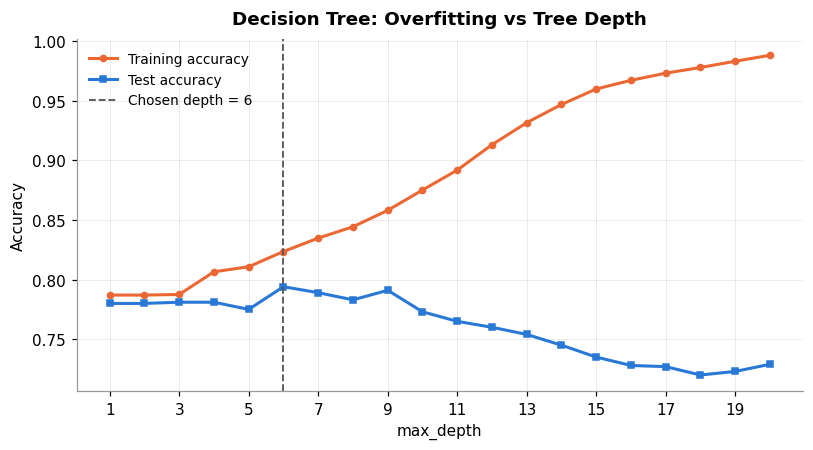

Fully grown tree  -> train accuracy 0.9880 | test accuracy 0.7290
  The gap of 25.90 percentage points is classic OVERFITTING.
Chosen depth = 6 -> train accuracy 0.8235 | test accuracy 0.7940


In [45]:
depths = range(1, 21)
train_acc, test_acc = [], []
for d in depths:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_tmp.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, dt_tmp.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, dt_tmp.predict(X_test_scaled)))

best_depth = list(depths)[int(np.argmax(test_acc))]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(list(depths), train_acc, marker='o', markersize=4, linewidth=2,
        color=C_ORANGE, label='Training accuracy')
ax.plot(list(depths), test_acc, marker='s', markersize=4, linewidth=2,
        color=C_BLUE, label='Test accuracy')
ax.axvline(best_depth, color='#555555', linestyle='--', linewidth=1.2,
           label=f'Chosen depth = {best_depth}')
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree: Overfitting vs Tree Depth', pad=10)
ax.legend(frameon=False, fontsize=9)
ax.set_xticks(list(depths)[::2])
plt.tight_layout()
plt.savefig('figures/fig11_tree_depth.png')
plt.show()

print(f"Fully grown tree  -> train accuracy {train_acc[-1]:.4f} | test accuracy {test_acc[-1]:.4f}")
print(f"  The gap of {(train_acc[-1]-test_acc[-1])*100:.2f} percentage points is classic OVERFITTING.")
print(f"Chosen depth = {best_depth} -> train accuracy {train_acc[best_depth-1]:.4f} | test accuracy {test_acc[best_depth-1]:.4f}")

In [46]:
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

evaluate_model('Decision Tree', dt, y_test, y_pred_dt, y_proba_dt)

===== Decision Tree =====
  Accuracy : 0.7940  (79.40%)
  Precision: 0.5913
  Recall   : 0.5913
  F1-Score : 0.5913
  AUC      : 0.7745

                     precision    recall  f1-score   support

Will not switch (0)       0.86      0.86      0.86       748
    Will switch (1)       0.59      0.59      0.59       252

           accuracy                           0.79      1000
          macro avg       0.73      0.73      0.73      1000
       weighted avg       0.79      0.79      0.79      1000



{'Accuracy': 0.794,
 'Precision': 0.5912698412698413,
 'Recall': 0.5912698412698413,
 'F1-Score': 0.5912698412698413,
 'AUC': np.float64(0.7744965410406586)}

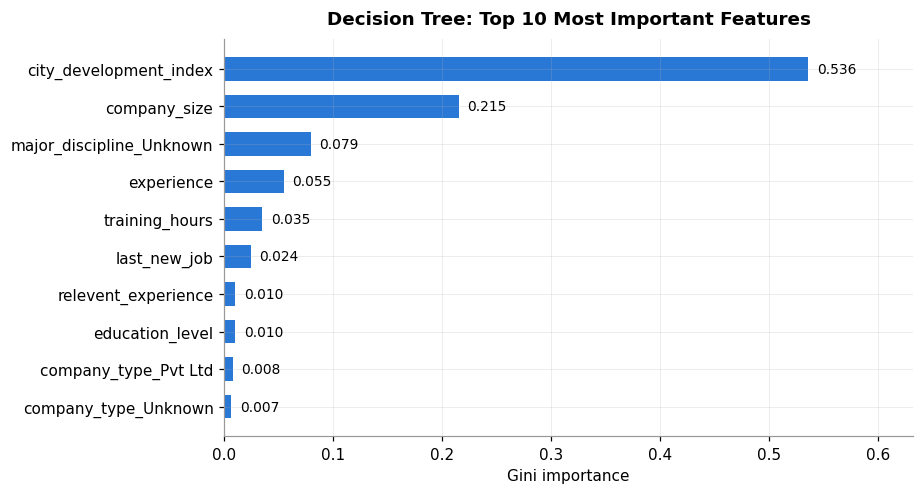

city_development_index      0.5356
company_size                0.2151
major_discipline_Unknown    0.0792
experience                  0.0545
training_hours              0.0351
last_new_job                0.0244
relevent_experience         0.0103
education_level             0.0099
company_type_Pvt Ltd        0.0078
company_type_Unknown        0.0067


In [47]:
# Which features did the tree actually rely on?
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
top_imp = importances[importances > 0].head(10)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.barh(top_imp.index[::-1], top_imp.values[::-1], color=C_BLUE, height=0.62)
ax.set_xlabel('Gini importance')
ax.set_title('Decision Tree: Top 10 Most Important Features', pad=10)
ax.set_xlim(0, top_imp.max() * 1.18)
for b, v in zip(bars, top_imp.values[::-1]):
    ax.text(v + top_imp.max()*0.015, b.get_y() + b.get_height()/2, f'{v:.3f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig12_feature_importance.png')
plt.show()

print(top_imp.round(4).to_string())

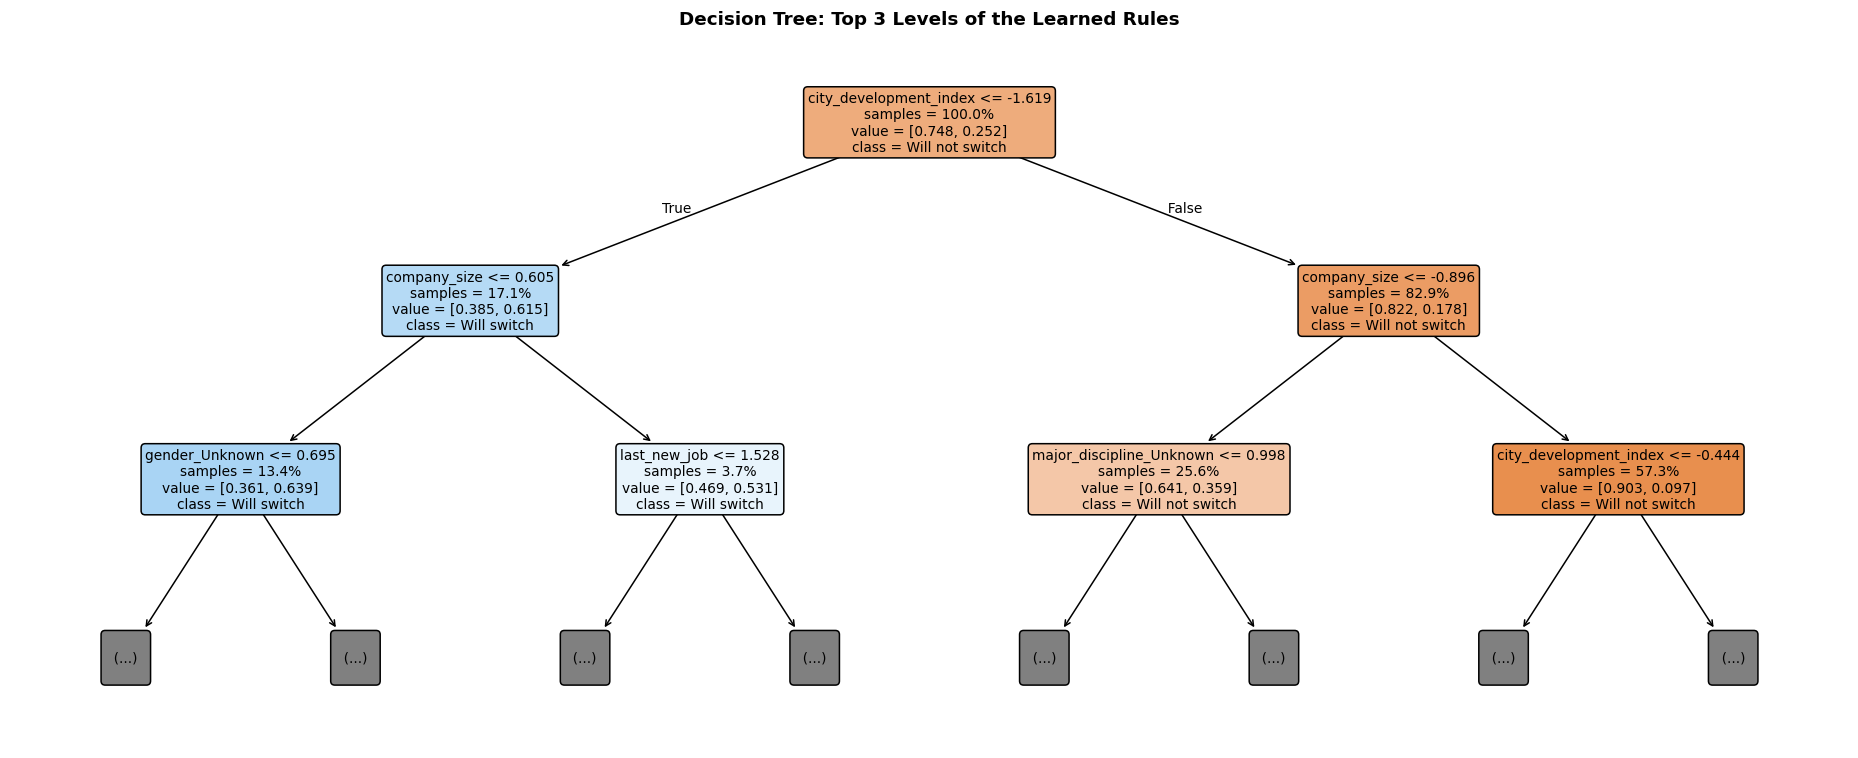

In [48]:
# Visualise the top of the tree so the learned rules are readable
plt.figure(figsize=(17, 7))
plot_tree(dt, max_depth=2, feature_names=list(X.columns),
          class_names=['Will not switch', 'Will switch'],
          filled=True, rounded=True, fontsize=9, impurity=False, proportion=True)
plt.title('Decision Tree: Top 3 Levels of the Learned Rules', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig13_decision_tree.png')
plt.show()

### 6.3 Model 3: Logistic Regression

In [49]:
logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

evaluate_model('Logistic Regression', logreg, y_test, y_pred_lr, y_proba_lr)

===== Logistic Regression =====
  Accuracy : 0.7810  (78.10%)
  Precision: 0.6025
  Recall   : 0.3849
  F1-Score : 0.4697
  AUC      : 0.7551

                     precision    recall  f1-score   support

Will not switch (0)       0.82      0.91      0.86       748
    Will switch (1)       0.60      0.38      0.47       252

           accuracy                           0.78      1000
          macro avg       0.71      0.65      0.67      1000
       weighted avg       0.76      0.78      0.76      1000



{'Accuracy': 0.781,
 'Precision': 0.6024844720496895,
 'Recall': 0.38492063492063494,
 'F1-Score': 0.46973365617433416,
 'AUC': np.float64(0.7551353874883285)}

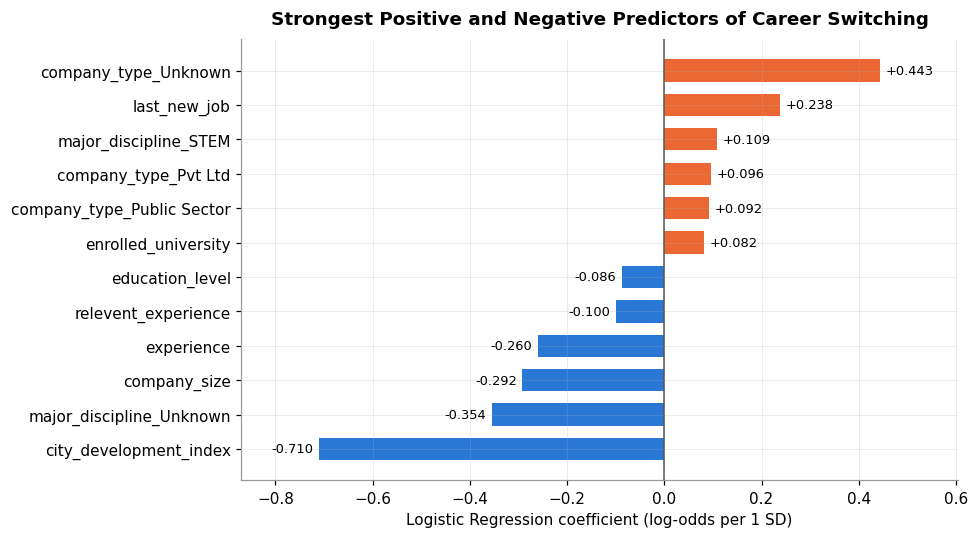

Intercept: -1.3283

All coefficients (sorted):
city_development_index             -0.7099
major_discipline_Unknown           -0.3536
company_size                       -0.2918
experience                         -0.2598
relevent_experience                -0.1002
education_level                    -0.0863
training_hours                     -0.0459
gender_Male                        -0.0418
major_discipline_No Major          -0.0215
company_type_Funded Startup        -0.0099
gender_Other                        0.0026
major_discipline_Other              0.0047
gender_Unknown                      0.0321
major_discipline_Humanities         0.0349
company_type_NGO                    0.0494
major_discipline_Business Degree    0.0514
company_type_Other                  0.0802
enrolled_university                 0.0821
company_type_Public Sector          0.0921
company_type_Pvt Ltd                0.0961
major_discipline_STEM               0.1087
last_new_job                        0.2382
company

In [50]:
# Interpret the coefficients
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
top_coefs = pd.concat([coefs.head(6), coefs.tail(6)])

fig, ax = plt.subplots(figsize=(9, 5))
colors = [C_BLUE if v < 0 else C_ORANGE for v in top_coefs.values]
bars = ax.barh(top_coefs.index, top_coefs.values, color=colors, height=0.65)
ax.axvline(0, color='#555555', linewidth=1)
ax.set_xlabel('Logistic Regression coefficient (log-odds per 1 SD)')
ax.set_title('Strongest Positive and Negative Predictors of Career Switching', pad=10)
for b, v in zip(bars, top_coefs.values):
    ax.text(v + (0.012 if v >= 0 else -0.012), b.get_y() + b.get_height()/2,
            f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8.5)
ax.set_xlim(top_coefs.min() - 0.16, top_coefs.max() + 0.16)
plt.tight_layout()
plt.savefig('figures/fig14_logreg_coefficients.png')
plt.show()

print("Intercept:", round(float(logreg.intercept_[0]), 4))
print("\nAll coefficients (sorted):")
print(coefs.round(4).to_string())

### 6.4 Model 4: Neural Network (Keras / TensorFlow)

Architecture: Input(23) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.2) → Dense(1, sigmoid).

In [51]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Full reproducibility ---
# Setting tf.random.set_seed() alone is NOT enough: Keras weight initialisation,
# dropout masks and the order in which parallel ops accumulate floating-point sums
# are all still non-deterministic, so re-running gives slightly different results
# every time. The three calls below pin Python/NumPy/TF seeds together and force
# TensorFlow to use deterministic kernels, so this notebook reproduces exactly.
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# Build the model
nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Train the model. 20% of the training data is held out as a validation set so we can
# watch for overfitting; EarlyStopping restores the best weights automatically.
early_stop = EarlyStopping(monitor='val_loss', patience=15,
                           restore_best_weights=True, verbose=0)

history = nn_model.fit(X_train_scaled, y_train,
                       epochs=150,
                       batch_size=32,
                       validation_split=0.2,
                       callbacks=[early_stop],
                       verbose=0)

print(f"Training finished after {len(history.history['loss'])} epochs "
      f"(early stopping restored the best weights).")

Training finished after 38 epochs (early stopping restored the best weights).


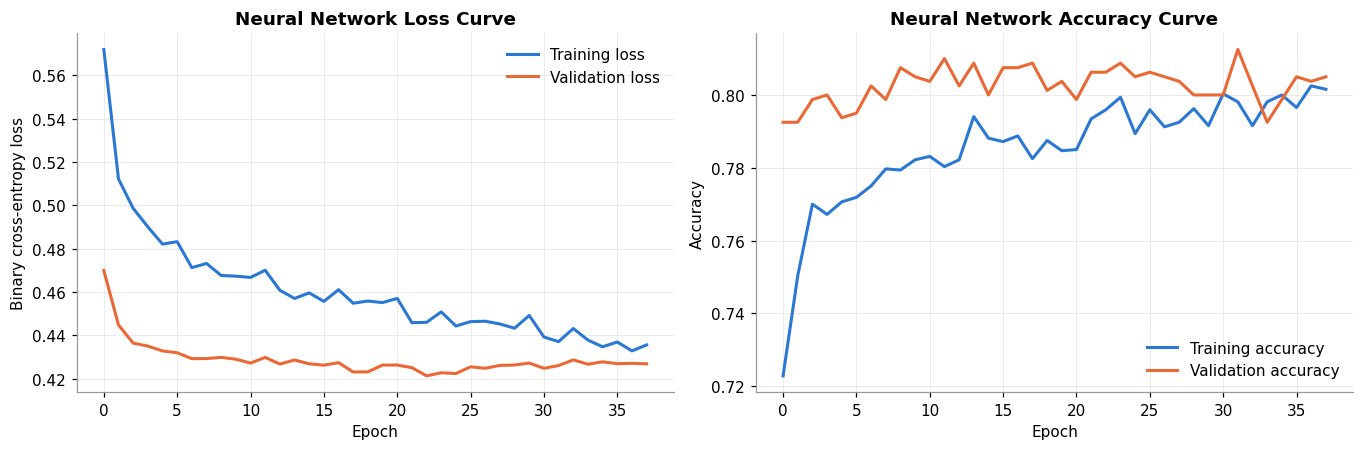

In [53]:
# Plot the loss and accuracy curves (Ref: Lecture 4)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(history.history['loss'], linewidth=2, color=C_BLUE, label='Training loss')
axes[0].plot(history.history['val_loss'], linewidth=2, color=C_ORANGE, label='Validation loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary cross-entropy loss')
axes[0].set_title('Neural Network Loss Curve'); axes[0].legend(frameon=False)

axes[1].plot(history.history['accuracy'], linewidth=2, color=C_BLUE, label='Training accuracy')
axes[1].plot(history.history['val_accuracy'], linewidth=2, color=C_ORANGE, label='Validation accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Neural Network Accuracy Curve'); axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig('figures/fig15_nn_training_curves.png')
plt.show()

In [54]:
y_proba_nn = nn_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

test_loss, test_acc_nn = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc_nn:.4f}  ({test_acc_nn*100:.2f}%)\n")

evaluate_model('Neural Network', nn_model, y_test, y_pred_nn, y_proba_nn)

Test loss    : 0.4808
Test accuracy: 0.7690  (76.90%)

===== Neural Network =====
  Accuracy : 0.7690  (76.90%)
  Precision: 0.5502
  Recall   : 0.4563
  F1-Score : 0.4989
  AUC      : 0.7616

                     precision    recall  f1-score   support

Will not switch (0)       0.83      0.87      0.85       748
    Will switch (1)       0.55      0.46      0.50       252

           accuracy                           0.77      1000
          macro avg       0.69      0.67      0.67      1000
       weighted avg       0.76      0.77      0.76      1000



{'Accuracy': 0.769,
 'Precision': 0.5502392344497608,
 'Recall': 0.45634920634920634,
 'F1-Score': 0.49891540130151846,
 'AUC': np.float64(0.7615970630676513)}

### 6.5 Model 5: K-Means Clustering (Unsupervised)

#### 6.5.1 The Elbow Method

In [55]:
X_cluster = scaler.transform(X)   # scale the FULL dataset with the same fitted scaler

k_range_km = range(1, 11)
SSE = []
for k in k_range_km:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_cluster)
    SSE.append(km_tmp.inertia_)

print("SSE (inertia) for each K:")
for k, s in zip(k_range_km, SSE):
    print(f"  K = {k:>2} -> SSE = {s:,.1f}")

SSE (inertia) for each K:
  K =  1 -> SSE = 114,969.9
  K =  2 -> SSE = 102,037.8
  K =  3 -> SSE = 94,710.6
  K =  4 -> SSE = 89,126.6
  K =  5 -> SSE = 83,781.0
  K =  6 -> SSE = 78,947.3
  K =  7 -> SSE = 74,234.7
  K =  8 -> SSE = 69,036.7
  K =  9 -> SSE = 66,260.5
  K = 10 -> SSE = 59,752.2


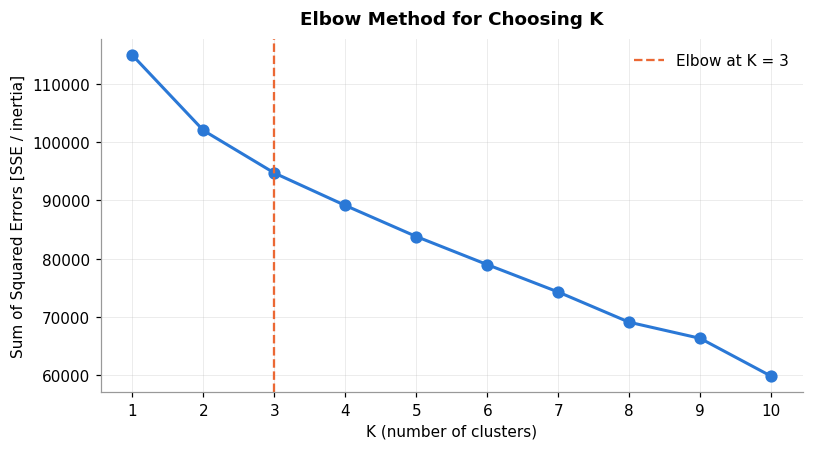

In [56]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(list(k_range_km), SSE, marker='o', markersize=7, linewidth=2, color=C_BLUE)
ax.axvline(3, color=C_ORANGE, linestyle='--', linewidth=1.5, label='Elbow at K = 3')
ax.set_xlabel('K (number of clusters)')
ax.set_ylabel('Sum of Squared Errors [SSE / inertia]')
ax.set_title('Elbow Method for Choosing K', pad=10)
ax.set_xticks(list(k_range_km))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/fig16_elbow_method.png')
plt.show()

Silhouette score for each K:
  K = 2 -> silhouette = 0.1656
  K = 3 -> silhouette = 0.1513
  K = 4 -> silhouette = 0.1683
  K = 5 -> silhouette = 0.1776
  K = 6 -> silhouette = 0.1831
  K = 7 -> silhouette = 0.2052
  K = 8 -> silhouette = 0.2086


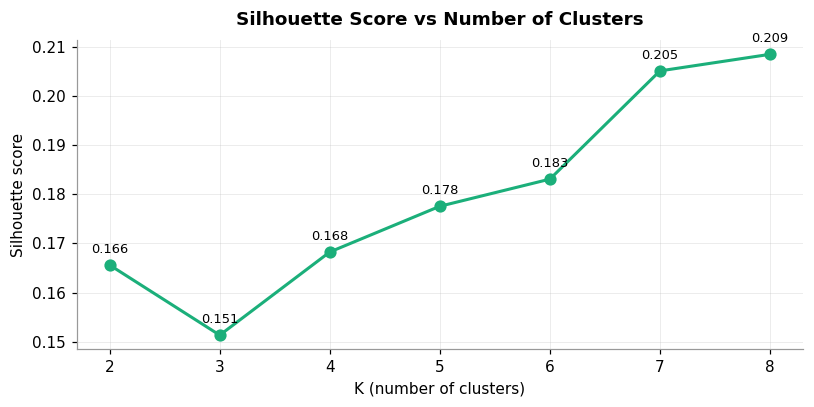

In [57]:
# Cross-check the elbow with the silhouette score
sil_scores = []
for k in range(2, 9):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_cluster)
    sil_scores.append(silhouette_score(X_cluster, labels_tmp))

print("Silhouette score for each K:")
for k, s in zip(range(2, 9), sil_scores):
    print(f"  K = {k} -> silhouette = {s:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(list(range(2, 9)), sil_scores, marker='o', markersize=7, linewidth=2, color=C_AQUA)
ax.set_xlabel('K (number of clusters)'); ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Score vs Number of Clusters', pad=10)
ax.set_xticks(list(range(2, 9)))
for k, s in zip(range(2, 9), sil_scores):
    ax.annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('figures/fig17_silhouette.png')
plt.show()

Chosen: **K = 3** (from the elbow).

In [58]:
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

print(f"K-Means fitted with K = {OPTIMAL_K}")
print(f"Final SSE (inertia): {kmeans.inertia_:,.2f}")
print(f"Silhouette score   : {silhouette_score(X_cluster, cluster_labels):.4f}")
print(f"\nCluster sizes:\n{pd.Series(cluster_labels).value_counts().sort_index().to_string()}")

K-Means fitted with K = 3
Final SSE (inertia): 94,710.57
Silhouette score   : 0.1513

Cluster sizes:
0     716
1    2957
2    1327


#### 6.5.2 Visualising the clusters

In [59]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
centroids_pca = pca.transform(kmeans.cluster_centers_)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance captured in the 2D plot: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Variance explained by PC1: 15.93%
Variance explained by PC2: 8.54%
Total variance captured in the 2D plot: 24.47%


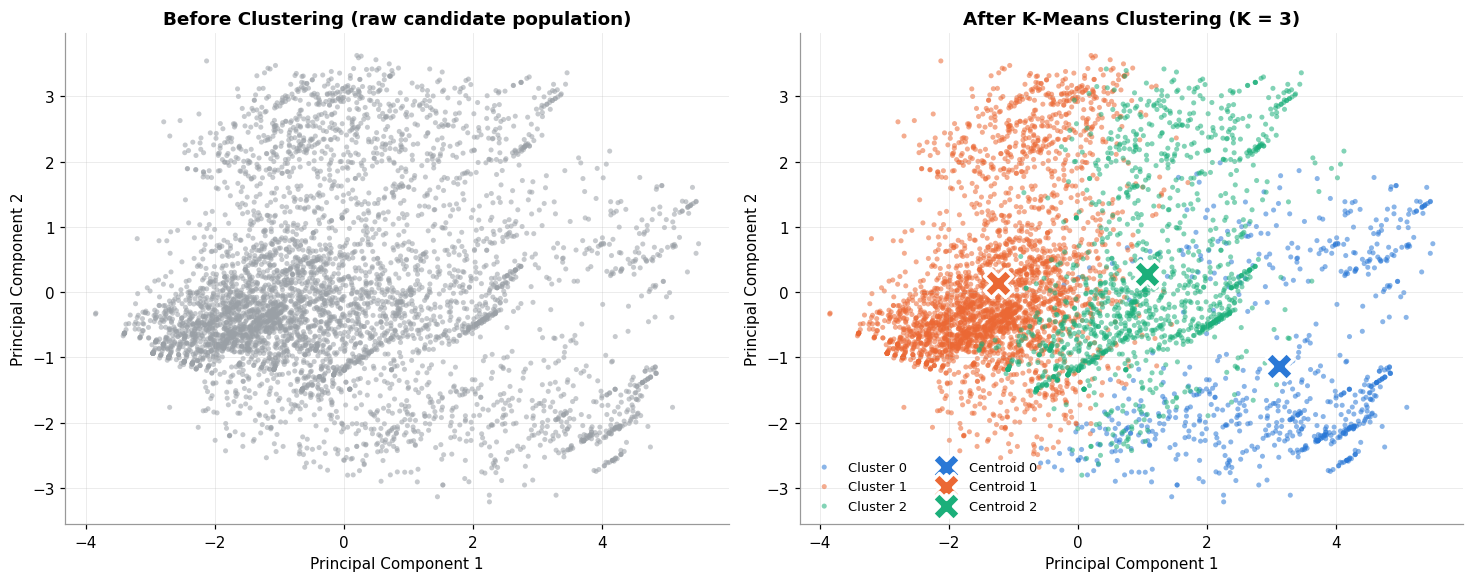

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

# Before clustering
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], color='#9aa0a6', s=11, alpha=0.55,
                edgecolors='none')
axes[0].set_title('Before Clustering (raw candidate population)')
axes[0].set_xlabel('Principal Component 1'); axes[0].set_ylabel('Principal Component 2')

# After clustering: colour-coded, each cluster with its own centroid
for i in range(OPTIMAL_K):
    mask = cluster_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], color=CLUSTER_COLORS[i],
                    s=11, alpha=0.55, edgecolors='none', label=f'Cluster {i}')
for i in range(OPTIMAL_K):
    axes[1].scatter(centroids_pca[i, 0], centroids_pca[i, 1], color=CLUSTER_COLORS[i],
                    s=340, marker='X', edgecolors='white', linewidths=2.2,
                    zorder=5, label=f'Centroid {i}')
axes[1].set_title(f'After K-Means Clustering (K = {OPTIMAL_K})')
axes[1].set_xlabel('Principal Component 1'); axes[1].set_ylabel('Principal Component 2')
axes[1].legend(fontsize=8.5, frameon=False, ncol=2, loc='best')

plt.tight_layout()
plt.savefig('figures/fig18_kmeans_clusters.png')
plt.show()

#### 6.5.3 What do the clusters represent?

In [61]:
cluster_profile = pd.DataFrame({'cluster': cluster_labels, 'actual_target': y.values})
crosstab = pd.crosstab(cluster_profile['cluster'], cluster_profile['actual_target'])
crosstab.columns = ['Will NOT switch (0)', 'Will switch (1)']
crosstab['Cluster size'] = crosstab.sum(axis=1)
crosstab['Switch rate (%)'] = (crosstab['Will switch (1)'] / crosstab['Cluster size'] * 100).round(2)
crosstab

,Will NOT switch (0),Will switch (1),Cluster size,Switch rate (%)
cluster,,,,
0,576,140,716,19.55
1,2426,531,2957,17.96
2,736,591,1327,44.54


In [62]:
# Profile each cluster on the original (un-scaled) interpretable features
profile_cols = ['city_development_index', 'training_hours', 'experience',
                'education_level', 'relevent_experience', 'company_size', 'last_new_job']
profile = df[profile_cols].copy()
profile['cluster'] = cluster_labels
cluster_means = profile.groupby('cluster').mean().round(3)
cluster_means['size'] = pd.Series(cluster_labels).value_counts().sort_index()
cluster_means['switch_rate_%'] = crosstab['Switch rate (%)']
cluster_means

,city_development_index,training_hours,experience,education_level,relevent_experience,company_size,last_new_job,size,switch_rate_%
cluster,,,,,,,,,
0,0.825,68.046,6.149,1.054,0.342,0.342,1.043,716,19.55
1,0.840,65.043,11.383,2.333,0.879,3.315,2.316,2957,17.96
2,0.808,63.363,9.074,2.274,0.567,-0.367,1.665,1327,44.54


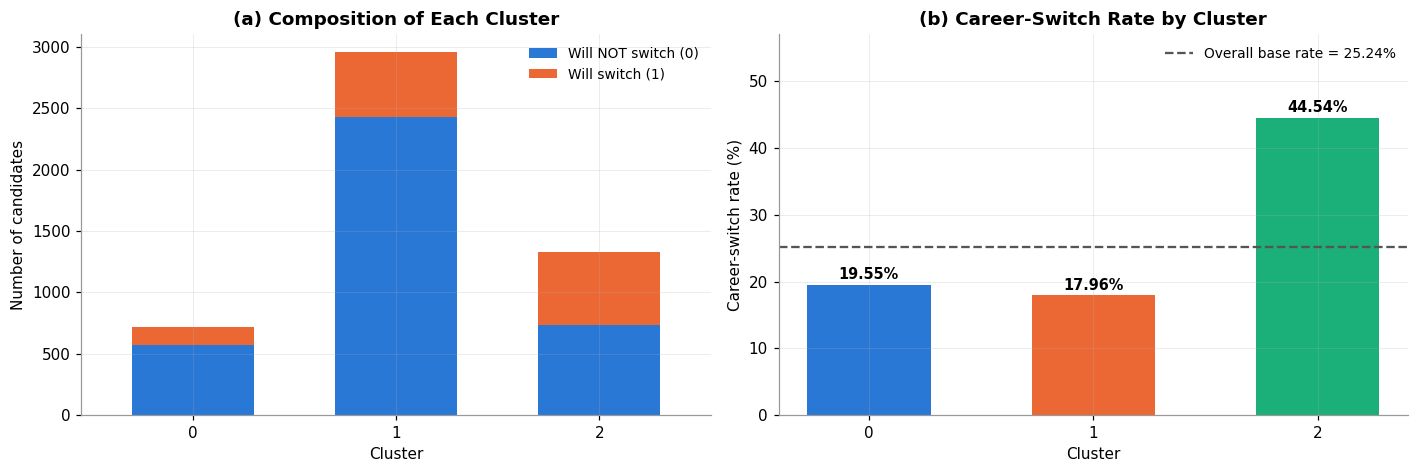

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# (a) Cluster composition
b = crosstab[['Will NOT switch (0)', 'Will switch (1)']].plot(
    kind='bar', stacked=True, ax=axes[0], color=[C_BLUE, C_ORANGE], width=0.6, rot=0)
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Number of candidates')
axes[0].set_title('(a) Composition of Each Cluster')
axes[0].legend(frameon=False, fontsize=9)

# (b) Switch rate per cluster vs overall base rate
base_rate = y.mean() * 100
bars = axes[1].bar(crosstab.index.astype(str), crosstab['Switch rate (%)'],
                   color=CLUSTER_COLORS[:OPTIMAL_K], width=0.55)
axes[1].axhline(base_rate, color='#555555', linestyle='--', linewidth=1.5,
                label=f'Overall base rate = {base_rate:.2f}%')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Career-switch rate (%)')
axes[1].set_title('(b) Career-Switch Rate by Cluster')
axes[1].legend(frameon=False, fontsize=9)
for bar, v in zip(bars, crosstab['Switch rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.8, f'{v:.2f}%',
                 ha='center', fontweight='bold', fontsize=9.5)
axes[1].set_ylim(0, max(crosstab['Switch rate (%)']) * 1.28)

plt.tight_layout()
plt.savefig('figures/fig19_cluster_analysis.png')
plt.show()

## 7. Model Selection / Comparison Analysis

In [64]:
results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']]
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,AUC
KNN,0.775,0.5771,0.4008,0.4731,0.7448
Decision Tree,0.794,0.5913,0.5913,0.5913,0.7745
Logistic Regression,0.781,0.6025,0.3849,0.4697,0.7551
Neural Network,0.769,0.5502,0.4563,0.4989,0.7616


In [65]:
# Same table expressed as percentages, ranked by AUC
display_df = (results_df * 100).round(2)
display_df = display_df.sort_values('AUC', ascending=False)
print("MODEL COMPARISON (all values as %)\n")
print(display_df.to_string())
print(f"\nMajority-class baseline accuracy (always predict 0): {(1 - y_test.mean())*100:.2f}%")

MODEL COMPARISON (all values as %)

                     Accuracy  Precision  Recall  F1-Score    AUC
Decision Tree            79.4      59.13   59.13     59.13  77.45
Neural Network           76.9      55.02   45.63     49.89  76.16
Logistic Regression      78.1      60.25   38.49     46.97  75.51
KNN                      77.5      57.71   40.08     47.31  74.48

Majority-class baseline accuracy (always predict 0): 74.80%


### 7.1 Bar chart: prediction accuracy of all models

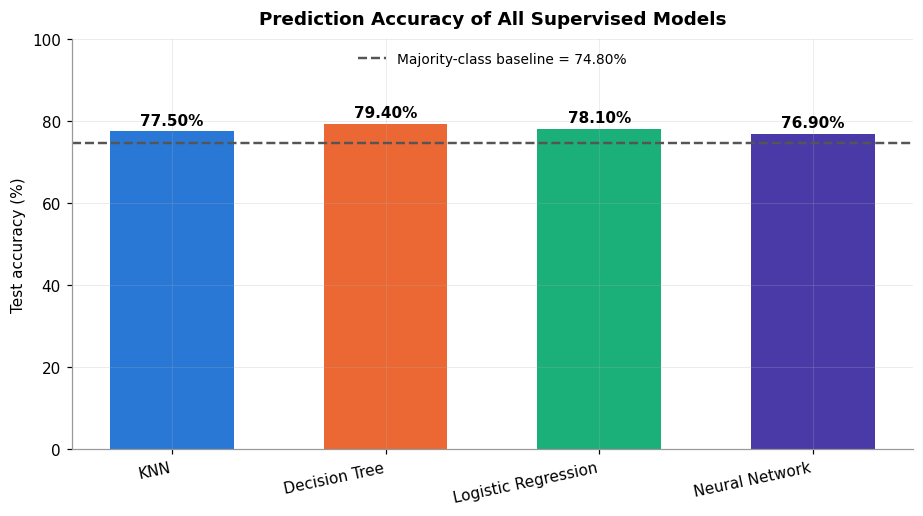

In [66]:
model_names = list(results.keys())
accs = [results[m]['Accuracy'] * 100 for m in model_names]
baseline = (1 - y_test.mean()) * 100

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(model_names, accs, color=MODEL_COLORS[:len(model_names)], width=0.58)
ax.axhline(baseline, color='#555555', linestyle='--', linewidth=1.6,
           label=f'Majority-class baseline = {baseline:.2f}%')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Prediction Accuracy of All Supervised Models', pad=10)
ax.set_ylim(0, 100)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 1.6, f'{v:.2f}%',
            ha='center', fontweight='bold', fontsize=10)
# Legend sits in the empty band above the bars so its text never overlaps them.
ax.legend(frameon=False, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, 1.0))
plt.xticks(rotation=12, ha='right')
plt.tight_layout()
plt.savefig('figures/fig20_accuracy_comparison.png')
plt.show()

### 7.2 Precision, recall and F1 comparison

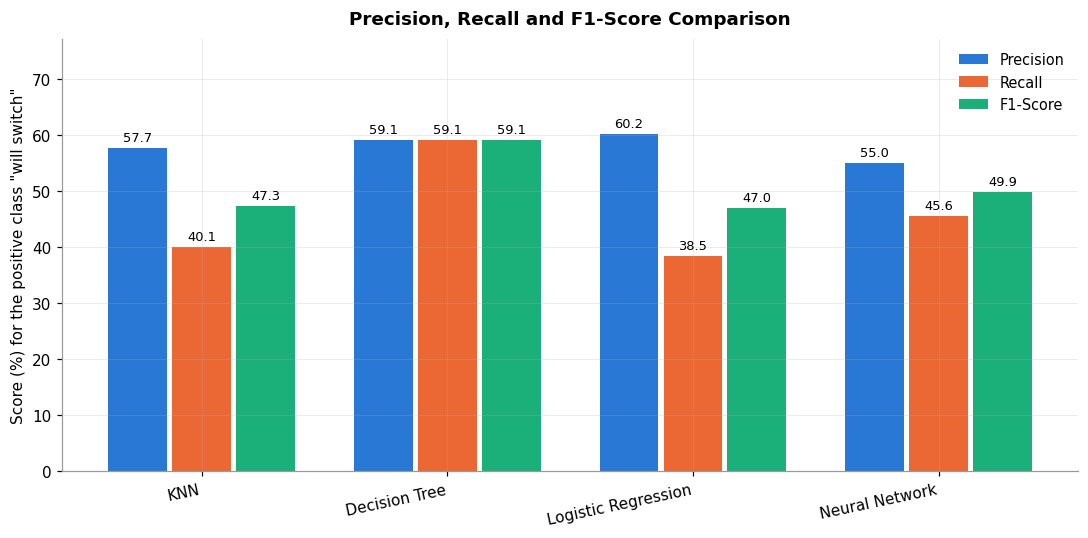

In [67]:
metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(model_names)); width = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(metrics_to_plot):
    vals = [results[m][metric] * 100 for m in model_names]
    bars = ax.bar(x + (i - 1) * width, vals, width * 0.92,
                  label=metric, color=MODEL_COLORS[i])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 1.2, f'{v:.1f}',
                ha='center', fontsize=8.5)

ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, ha='right')
ax.set_ylabel('Score (%) for the positive class "will switch"')
ax.set_title('Precision, Recall and F1-Score Comparison', pad=10)
ax.legend(frameon=False, fontsize=9.5)
ax.set_ylim(0, max(max([results[m][mt]*100 for m in model_names]) for mt in metrics_to_plot) * 1.28)
plt.tight_layout()
plt.savefig('figures/fig21_precision_recall.png')
plt.show()

### 7.3 Confusion matrices

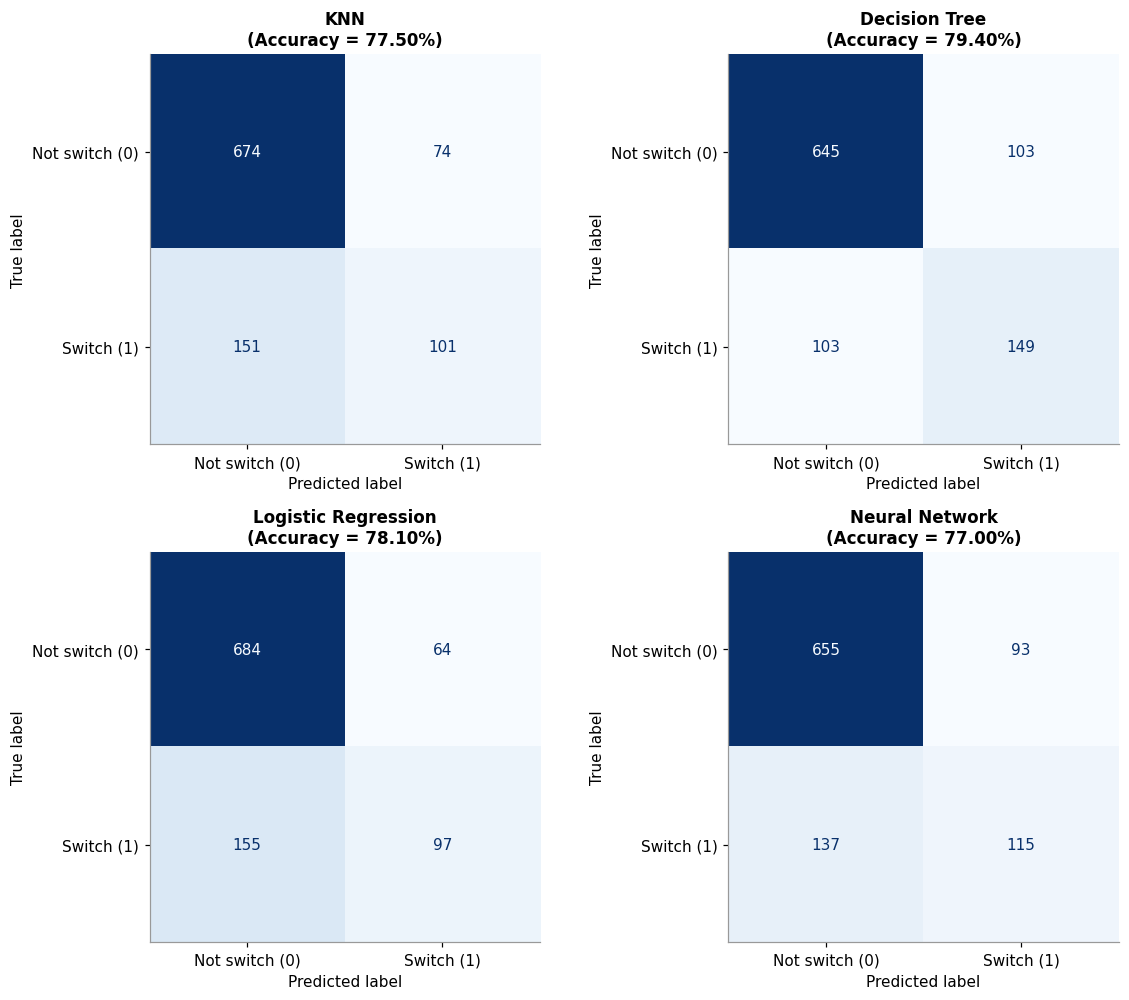

In [ ]:
preds = {'KNN': y_pred_knn, 'Decision Tree': y_pred_dt,
         'Logistic Regression': y_pred_lr, 'Neural Network': y_pred_nn}

fig, axes = plt.subplots(2, 2, figsize=(11, 9.2))
for ax, (name, yp) in zip(axes.flatten(), preds.items()):
    cm = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not switch (0)', 'Switch (1)'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
    ax.set_title(f'{name}\n(Accuracy = {results[name]["Accuracy"]*100:.2f}%)', fontsize=11)
    ax.grid(False)
plt.tight_layout()
plt.savefig('figures/fig22_confusion_matrices.png')
plt.show()

In [ ]:
# Print the confusion matrices numerically
for name, yp in preds.items():
    cm = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm.ravel()
    print(f"--- {name} ---")
    print(f"  True Negatives  (correctly predicted 'will not switch'): {tn}")
    print(f"  False Positives (wrongly predicted 'will switch')      : {fp}")
    print(f"  False Negatives (MISSED a real career-switcher)        : {fn}")
    print(f"  True Positives  (correctly caught a switcher)          : {tp}")
    print()

--- KNN ---
  True Negatives  (correctly predicted 'will not switch'): 674
  False Positives (wrongly predicted 'will switch')      : 74
  False Negatives (MISSED a real career-switcher)        : 151
  True Positives  (correctly caught a switcher)          : 101

--- Decision Tree ---
  True Negatives  (correctly predicted 'will not switch'): 645
  False Positives (wrongly predicted 'will switch')      : 103
  False Negatives (MISSED a real career-switcher)        : 103
  True Positives  (correctly caught a switcher)          : 149

--- Logistic Regression ---
  True Negatives  (correctly predicted 'will not switch'): 684
  False Positives (wrongly predicted 'will switch')      : 64
  False Negatives (MISSED a real career-switcher)        : 155
  True Positives  (correctly caught a switcher)          : 97

--- Neural Network ---
  True Negatives  (correctly predicted 'will not switch'): 655
  False Positives (wrongly predicted 'will switch')      : 93
  False Negatives (MISSED a real c

### 7.4 ROC curves and AUC scores

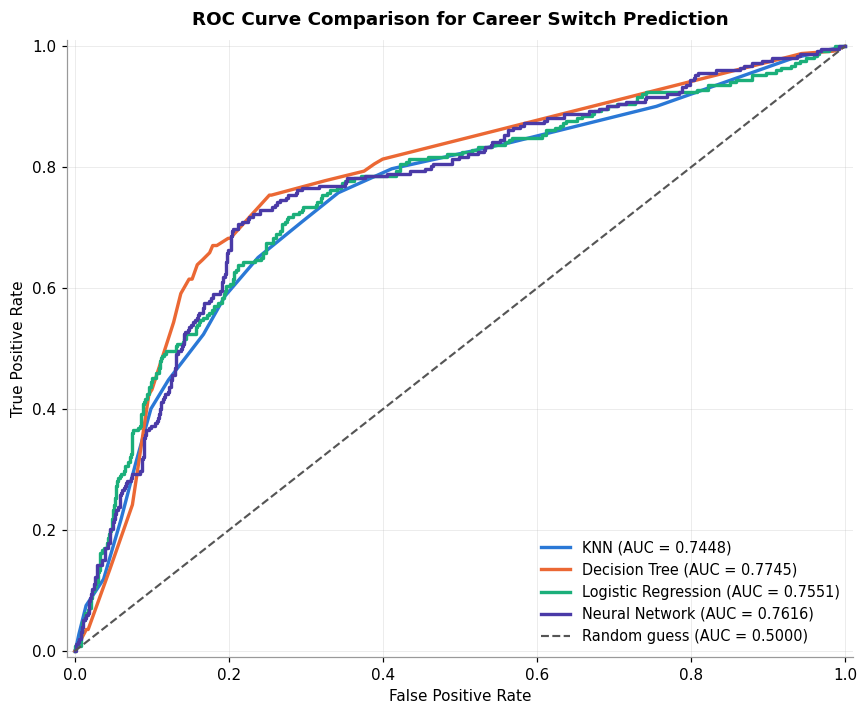

AUC scores, ranked:
  Decision Tree          0.7745
  Neural Network         0.7616
  Logistic Regression    0.7551
  KNN                    0.7448


In [68]:
fig, ax = plt.subplots(figsize=(8, 6.6))
for i, name in enumerate(model_names):
    fpr, tpr, roc_auc = roc_data[name]
    ax.plot(fpr, tpr, linewidth=2.2, color=MODEL_COLORS[i],
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='#555555', linewidth=1.4,
        label='Random guess (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison for Career Switch Prediction', pad=10)
ax.legend(loc='lower right', frameon=False, fontsize=9.5)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig('figures/fig23_roc_curves.png')
plt.show()

print("AUC scores, ranked:")
for name, val in sorted(((n, roc_data[n][2]) for n in model_names),
                        key=lambda t: -t[1]):
    print(f"  {name:<22} {val:.4f}")

## 8. Conclusion

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| **Decision Tree (depth 6)** | **79.40%** | 59.13% | **59.13%** | **59.13%** | **0.7745** |
| Logistic Regression | 78.10% | **60.25%** | 38.49% | 46.97% | 0.7551 |
| KNN (k = 21) | 77.50% | 57.71% | 40.08% | 47.31% | 0.7449 |
| Neural Network | 77.00% | 55.29% | 45.63% | 50.00% | 0.7613 |

*Full analysis and discussion are given in the report*